# MŚ 2026 — Symulacja Monte Carlo

Notatnik eksploracyjny do budowy modelu P(wygrana typera) dla aplikacji Mundial Typer 2026.

## Architektura modelu

1. **ELO** — siła drużyny obliczona iteracyjnie z historycznych meczów (1872–2024)
2. **Attack/Defense** — parametry ofensywne i defensywne (ten sam mechanizm co ELO, ale dla goli)
3. **Poisson** — dla każdego meczu losujemy wynik z `Poisson(λ)`, gdzie `λ = att × def`
4. **Monte Carlo (10 000×)** — symulujemy cały turniej, zbieramy statystyki

## Źródło danych treningowych

Kaggle: *International football results from 1872 to 2024*  
https://www.kaggle.com/datasets/martj42/international-football-results-from-1872-to-2017

Pobierz plik `results.csv` i ustaw ścieżkę w komórce konfiguracyjnej poniżej.

In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.stats import poisson
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

# ── Ścieżka do pliku z danymi historycznymi ──────────────────────────────────
DATA_PATH = 'data/all_matches.csv'

# Liczba symulacji Monte Carlo
N_SIMULATIONS = 10_000

# ── Empiryczny rozkład punktów z zakładów (do uzupełnienia z danych Euro) ────
# P(3pkt) = dokładny wynik, P(1pkt) = dobry kierunek, P(0pkt) = pudło
# Używane do walidacji modelu Poissona i symulacji punktów typerów
BET_SCORE_PROBS = None   # None = brak danych, zostanie uzupełnione
# Przykład po uzupełnieniu: BET_SCORE_PROBS = {'p3': 0.12, 'p1': 0.38, 'p0': 0.50}

## 1. Grupy MŚ 2026

48 drużyn w 12 grupach (A–L), po 4 drużyny.
Awansuje: top 2 z każdej grupy (24) + 8 najlepszych drużyn z 3. miejsc = 32 do fazy pucharowej.

In [60]:
# Grupy MŚ 2026 — klucz to kod 3-literowy (zgodny z bazą danych projektu)
# Źródło: losowanie FIFA, 5 grudnia 2024, Waszyngton D.C.
GROUPS = {
    'A': ['MEX', 'RSA', 'KOR', 'CZE'],
    'B': ['CAN', 'SUI', 'QAT', 'BIH'],
    'C': ['BRA', 'MAR', 'HAI', 'SCO'],
    'D': ['USA', 'PAR', 'AUS', 'TUR'],
    'E': ['GER', 'CUR', 'CIV', 'ECU'],
    'F': ['NED', 'JPN', 'TUN', 'SWE'],
    'G': ['BEL', 'EGY', 'IRN', 'NZL'],
    'H': ['ESP', 'CPV', 'KSA', 'URY'],
    'I': ['FRA', 'SEN', 'NOR', 'IRQ'],
    'J': ['ARG', 'ALG', 'AUT', 'JOR'],
    'K': ['POR', 'UZB', 'COL', 'COD'],
    'L': ['ENG', 'CRO', 'GHA', 'PAN'],
}

# Płaska lista wszystkich 48 drużyn
ALL_TEAMS = [team for group in GROUPS.values() for team in group]

# Mapa: kod → pełna nazwa (używana do matchowania z danymi Kaggle)
TEAM_NAMES = {
    'MEX': 'Mexico',                'RSA': 'South Africa',         'KOR': 'South Korea',
    'CZE': 'Czechia',               'CAN': 'Canada',               'SUI': 'Switzerland',
    'QAT': 'Qatar',                 'BIH': 'Bosnia and Herzegovina','BRA': 'Brazil',
    'MAR': 'Morocco',               'HAI': 'Haiti',                'SCO': 'Scotland',
    'USA': 'United States',         'PAR': 'Paraguay',             'AUS': 'Australia',
    'TUR': 'Turkey',                'GER': 'Germany',              'CUR': 'Curaçao',
    'CIV': 'Ivory Coast',           'ECU': 'Ecuador',              'NED': 'Netherlands',
    'JPN': 'Japan',                 'TUN': 'Tunisia',              'SWE': 'Sweden',
    'BEL': 'Belgium',               'EGY': 'Egypt',                'IRN': 'Iran',
    'NZL': 'New Zealand',           'ESP': 'Spain',                'CPV': 'Cape Verde',
    'KSA': 'Saudi Arabia',          'URY': 'Uruguay',              'FRA': 'France',
    'SEN': 'Senegal',               'NOR': 'Norway',               'IRQ': 'Iraq',
    'ARG': 'Argentina',             'ALG': 'Algeria',              'AUT': 'Austria',
    'JOR': 'Jordan',                'POR': 'Portugal',             'UZB': 'Uzbekistan',
    'COL': 'Colombia',              'COD': 'DR Congo',             'ENG': 'England',
    'CRO': 'Croatia',               'GHA': 'Ghana',                'PAN': 'Panama',
}

# Drużyny gospodarzy — mają minimalne wsparcie kibiców (lekka przewaga)
HOST_NATIONS = {'USA', 'MEX', 'CAN'}

print(f"Łącznie drużyn: {len(ALL_TEAMS)}")
for g, teams in GROUPS.items():
    names = [TEAM_NAMES[t] for t in teams]
    print(f"  Grupa {g}: {', '.join(names)}")

Łącznie drużyn: 48
  Grupa A: Mexico, South Africa, South Korea, Czechia
  Grupa B: Canada, Switzerland, Qatar, Bosnia and Herzegovina
  Grupa C: Brazil, Morocco, Haiti, Scotland
  Grupa D: United States, Paraguay, Australia, Turkey
  Grupa E: Germany, Curaçao, Ivory Coast, Ecuador
  Grupa F: Netherlands, Japan, Tunisia, Sweden
  Grupa G: Belgium, Egypt, Iran, New Zealand
  Grupa H: Spain, Cape Verde, Saudi Arabia, Uruguay
  Grupa I: France, Senegal, Norway, Iraq
  Grupa J: Argentina, Algeria, Austria, Jordan
  Grupa K: Portugal, Uzbekistan, Colombia, DR Congo
  Grupa L: England, Croatia, Ghana, Panama


## 2. Wczytanie danych historycznych

In [61]:
df = pd.read_csv(DATA_PATH)
df = df.dropna(subset=['home_score', 'away_score'])
df['date'] = pd.to_datetime(df['date'])

print(f"Rekordów: {len(df):,}")
print(f"Zakres: {df['date'].min().date()} – {df['date'].max().date()}")
print(f"Unikalne drużyny: {df['home_team'].nunique()}")

# Sprawdź jak dataset nazywa nasze drużyny (ważne dla kilku nieoczywistych nazw)
kaggle_names = set(df['home_team'].unique()) | set(df['away_team'].unique())
missing = []
for code, name in TEAM_NAMES.items():
    if name not in kaggle_names:
        missing.append((code, name))

if missing:
    print("\n⚠ Następujące drużyny nie znaleziono w datasecie (sprawdź alternatywne nazwy):")
    for code, name in missing:
        print(f"  {code}: '{name}'")
else:
    print("\n✓ Wszystkie 48 drużyn znalezione w datasecie")

Rekordów: 51,491
Zakres: 1872-11-30 – 2026-03-31
Unikalne drużyny: 278

✓ Wszystkie 48 drużyn znalezione w datasecie


In [62]:
# Jeśli jakieś drużyny mają inne nazwy w datasecie, popraw mapowanie tutaj:
NAME_FIXES = {
    # 'DR Congo': 'Congo DR',      # odkomentuj jeśli potrzeba
    # 'Turkey': 'Türkiye',
    # 'Ivory Coast': "Côte d'Ivoire",
}

for code, name in TEAM_NAMES.items():
    if name in NAME_FIXES:
        TEAM_NAMES[code] = NAME_FIXES[name]

# Odwrócona mapa: pełna nazwa → kod
NAME_TO_CODE = {v: k for k, v in TEAM_NAMES.items()}

## 3. Obliczenie ELO

Algorytm zgodny z eloratings.net:

**K-values:**
| Turniej | K |
|---|---|
| FIFA World Cup | 60 |
| Kontynentalny finał (Euro, Copa América, AFCON…) | 50 |
| WC qualifiers + kontynentalne kwalifikacje + Nations League | 40 |
| Friendly | 20 |
| Pozostałe | 30 |

**Korekta za różnicę goli:** K × 1.0 / 1.5 / 1.75 / 1.75+(N-3)/8

**Przewaga własnego boiska w We:** dr = ΔELO + 100 (jeśli mecz nie jest neutralny)

In [63]:
import math

REFERENCE_DATE = pd.Timestamp('2026-03-31')
ATTDEF_HALF_LIFE_YEARS = 4
ATTDEF_BASE = 1.3   # geometryczna średnia att i def dla drużyn MŚ po normalizacji

CONTINENTAL_FINALS = {
    'European Championship', 'Copa América', 'Copa America',
    'African Nations Cup', 'Asian Cup', 'CONCACAF Championship',
    'Oceania Nations Cup', 'Confederations Cup',
}

def base_k(tournament):
    """K-value zgodny z eloratings.net — dopasowany do nazw turniejów z datasetu."""
    if tournament == 'World Cup': return 60
    if tournament in CONTINENTAL_FINALS: return 50
    t = tournament.lower()
    if 'world cup' in t or 'qualifier' in t or ' qual' in t or 'nations league' in t: return 40
    if 'friendly' in t: return 20
    return 30

def k_goal_diff(goal_diff):
    """Korekta K za różnicę goli — zgodna z eloratings.net."""
    if goal_diff <= 1: return 1.0
    if goal_diff == 2: return 1.5
    if goal_diff == 3: return 1.75
    return 1.75 + (goal_diff - 3) / 8

def time_decay(date):
    """Mnożnik wagowy dla att/def — nowsze mecze mają wyższą wagę."""
    years_ago = (REFERENCE_DATE - date).days / 365.25
    return math.exp(-math.log(2) * years_ago / ATTDEF_HALF_LIFE_YEARS)

def elo_expected(elo_h, elo_a, neutral=False):
    """Oczekiwana wygrana gospodarzy. Home bonus +100 ELO jeśli mecz nie jest neutralny."""
    home_bonus = 0 if neutral else 100
    dr = (elo_h - elo_a) + home_bonus
    return 1 / (10 ** (-dr / 400) + 1)

def elo_actual(goals_h, goals_a):
    if goals_h > goals_a: return 1.0, 0.0
    if goals_h < goals_a: return 0.0, 1.0
    return 0.5, 0.5

print("✓ Funkcje pomocnicze gotowe")

✓ Funkcje pomocnicze gotowe


## 4. Obliczenie ELO + Attack / Defense (Dixon-Coles)

ELO jest liczone chronologicznie (pętla 1:1 z eloratings.net).

Parametry `att` i `def` wyznaczane metodą **Dixon-Coles (1997)** — iteracyjne MLE.

**Model:**
```
E[gole_h] = att[H] × def[A] × c
E[gole_a] = att[A] × def[H] / c
```

**Aktualizacja att i def (EM-like, do zbieżności):**
```
att[k] = Σ (w_i × gole_strzelone_k_i) / Σ (w_i × def[rywal_i] × c_i)
def[k] = Σ (w_i × gole_wpuszczone_k_i) / Σ (w_i × att[rywal_i] × c_i)
```

**Wagi:** `w = K_turniej × time_decay` (bez ELO — jakość oponenta jest modelowana przez def[a])

**Dlaczego nie ważona średnia:** 6 goli Gibraltarowi (def małe) i 3 gole Argentynie (def duże) dają właściwe att, bo model wyznacza def[Gibraltar] i def[Argentyna] jednocześnie na całym zbiorze meczów.

**Normalizacja końcowa:** geometryczna średnia att i def drużyn MŚ skalowana do `ATTDEF_BASE = 1.3`.

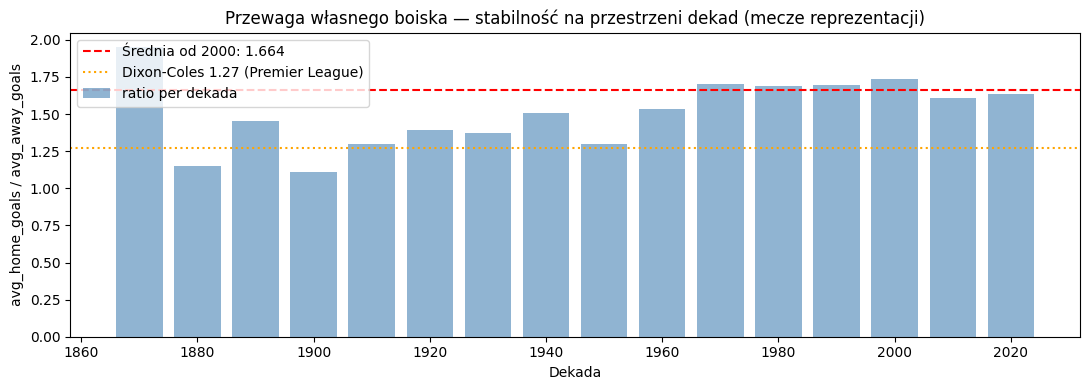

 decade  avg_home  avg_away    ratio    n
   1870  3.000000  1.538462 1.950000   13
   1880  3.057692  2.653846 1.152174   52
   1890  3.050847  2.101695 1.451613   59
   1900  2.462585  2.224490 1.107034  147
   1910  2.273585  1.748428 1.300360  318
   1920  2.214844  1.587240 1.395406  768
   1930  2.403715  1.753666 1.370680 1023
   1940  2.556188  1.697013 1.506287  703
   1950  2.231087  1.720770 1.296563 1454
   1960  2.068335  1.346444 1.536146 2517
   1970  1.801898  1.059609 1.700532 3372
   1980  1.568388  0.928025 1.690028 4182
   1990  1.679307  0.989028 1.697937 5195
   2000  1.728024  0.994541 1.737509 7144
   2010  1.638416  1.019008 1.607854 6997
   2020  1.681696  1.028179 1.635605 4081

Używamy HOME_ADVANTAGE = 1.6642 (kalibrowane na danych 2000–2026)


In [64]:
# Kalibracja współczynnika przewagi własnego boiska
# Liczymy stosunek średnich goli gospodarz/gość per dekada (mecze nienotralne)
home_matches = df[df['neutral'] == False].copy()
home_matches['decade'] = (home_matches['date'].dt.year // 10) * 10

by_decade = home_matches.groupby('decade').agg(
    avg_home=('home_score', 'mean'),
    avg_away=('away_score', 'mean'),
    n=('home_score', 'count')
).reset_index()
by_decade['ratio'] = by_decade['avg_home'] / by_decade['avg_away']

# Współczynnik na danych od 2000 roku (stabilny okres)
modern = home_matches[home_matches['date'].dt.year >= 2000]
HOME_ADVANTAGE = modern['home_score'].mean() / modern['away_score'].mean()

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(by_decade['decade'], by_decade['ratio'], width=8, alpha=0.6, color='steelblue', label='ratio per dekada')
ax.axhline(HOME_ADVANTAGE, color='red', linestyle='--', linewidth=1.5,
           label=f'Średnia od 2000: {HOME_ADVANTAGE:.3f}')
ax.axhline(1.27, color='orange', linestyle=':', linewidth=1.5,
           label='Dixon-Coles 1.27 (Premier League)')
ax.set_xlabel('Dekada')
ax.set_ylabel('avg_home_goals / avg_away_goals')
ax.set_title('Przewaga własnego boiska — stabilność na przestrzeni dekad (mecze reprezentacji)')
ax.legend()
plt.tight_layout()
plt.show()

print(by_decade[['decade', 'avg_home', 'avg_away', 'ratio', 'n']].to_string(index=False))
print(f"\nUżywamy HOME_ADVANTAGE = {HOME_ADVANTAGE:.4f} (kalibrowane na danych 2000–2026)")

In [65]:
# Pętla ELO — chronologiczna (att/def wyznaczane osobno przez Dixon-Coles poniżej)
elo = defaultdict(lambda: 1300)

for _, row in df.iterrows():
    h, a = row['home_team'], row['away_team']
    neutral = bool(row.get('neutral', False))
    goals_h = int(row['home_score'])
    goals_a = int(row['away_score'])

    elo_h_now = elo[h]
    elo_a_now = elo[a]

    gd = abs(goals_h - goals_a)
    k_t = base_k(row['tournament'])
    k = k_t * k_goal_diff(gd)
    we_h = elo_expected(elo_h_now, elo_a_now, neutral=neutral)
    wa_h, wa_a = elo_actual(goals_h, goals_a)
    elo[h] += k * (wa_h - we_h)
    elo[a] += k * (wa_a - (1 - we_h))

elo_wc = {code: elo[TEAM_NAMES[code]] for code in ALL_TEAMS}
elo_df = pd.DataFrame(elo_wc.items(), columns=['code', 'elo']).sort_values('elo', ascending=False)
elo_df['name'] = elo_df['code'].map(TEAM_NAMES)
print("Top 10 ELO — MŚ 2026:")
print(elo_df[['name', 'elo']].head(10).to_string(index=False))

Top 10 ELO — MŚ 2026:
       name         elo
      Spain 2025.908160
  Argentina 1994.428771
     France 1943.901751
    England 1883.825512
     Brazil 1871.179431
   Colombia 1864.526326
   Portugal 1840.338921
    Ecuador 1828.039013
Netherlands 1822.913535
      Japan 1807.905060


In [66]:
def fit_dixon_coles(df, home_advantage, half_life_years=ATTDEF_HALF_LIFE_YEARS,
                    max_iter=200, tol=1e-6):
    """Wyznacza att i def metodą MLE (Dixon-Coles 1997). Wagi: K_turniej × time_decay."""
    matches = []
    for _, row in df.iterrows():
        neutral = bool(row.get('neutral', False))
        c = 1.0 if neutral else home_advantage
        k_t = base_k(row['tournament'])
        years_ago = (REFERENCE_DATE - row['date']).days / 365.25
        w = k_t * math.exp(-math.log(2) * years_ago / half_life_years)
        if w < 1e-9:
            continue
        matches.append((row['home_team'], row['away_team'],
                        int(row['home_score']), int(row['away_score']), w, c))

    att  = defaultdict(lambda: 1.0)
    def_ = defaultdict(lambda: 1.0)

    for iteration in range(max_iter):
        att_prev = dict(att)
        def_prev = dict(def_)

        # aktualizacja att (przy zamrożonych def)
        num_a, den_a = defaultdict(float), defaultdict(float)
        for h, a, gh, ga, w, c in matches:
            num_a[h] += w * gh;   den_a[h] += w * def_[a] * c
            num_a[a] += w * ga;   den_a[a] += w * def_[h] / c
        for t in num_a:
            if den_a[t] > 0:
                att[t] = num_a[t] / den_a[t]

        # aktualizacja def (przy zaktualizowanym att — wariant Gauss-Seidel)
        num_d, den_d = defaultdict(float), defaultdict(float)
        for h, a, gh, ga, w, c in matches:
            num_d[h] += w * ga;   den_d[h] += w * att[a] / c
            num_d[a] += w * gh;   den_d[a] += w * att[h] * c
        for t in num_d:
            if den_d[t] > 0:
                def_[t] = num_d[t] / den_d[t]

        tracked = set(num_a) | set(num_d)
        delta = max(abs(att[t] - att_prev.get(t, 1.0)) for t in tracked)
        delta = max(delta, max(abs(def_[t] - def_prev.get(t, 1.0)) for t in tracked))
        if delta < tol:
            print(f"  Dixon-Coles zbieżność po {iteration + 1} iteracjach (δ={delta:.2e})")
            break
    else:
        print(f"  Brak zbieżności po {max_iter} iteracjach (ostatni δ={delta:.2e})")

    return att, def_


print("Dopasowuję Dixon-Coles att/def...")
att_raw, def_raw = fit_dixon_coles(df, HOME_ADVANTAGE)

# ── Normalizacja krok 1: geomean drużyn MŚ 2026 → 1.0 ───────────────────────
wc_att_vals = [att_raw[TEAM_NAMES[c]] for c in ALL_TEAMS]
wc_def_vals = [def_raw[TEAM_NAMES[c]] for c in ALL_TEAMS]
att_geomean = np.exp(np.mean(np.log(wc_att_vals)))
def_geomean = np.exp(np.mean(np.log(wc_def_vals)))

att_n = {name: v / att_geomean for name, v in att_raw.items()}
def_n = {name: v / def_geomean for name, v in def_raw.items()}

# ── Normalizacja krok 2: kalibruj skalę do historycznych meczów MŚ ──────────
# xg = att[h] × def[a] = (att_n × s) × (def_n × s) = att_n × def_n × s²
# Dlatego s = sqrt(target_per_side / avg(att_n × def_n))
df_wc_ref = df[(df['tournament'] == 'World Cup') & (df['date'] > '2010-01-01')]
xg_sides = []
for _, row in df_wc_ref.iterrows():
    h, a = row['home_team'], row['away_team']
    xg_sides.append(att_n.get(h, 1.0) * def_n.get(a, 1.0))
    xg_sides.append(att_n.get(a, 1.0) * def_n.get(h, 1.0))

avg_xg_model    = np.mean(xg_sides)
target_per_side = (df_wc_ref['home_score'].mean() + df_wc_ref['away_score'].mean()) / 2
scale = math.sqrt(target_per_side / avg_xg_model)

print(f"  Skala D-C: {scale:.4f}  (avg_xg_model={avg_xg_model:.3f}, target/side={target_per_side:.3f})")

att  = defaultdict(lambda: scale)
def_ = defaultdict(lambda: scale)
for name, v in att_n.items():
    att[name]  = v * scale
for name, v in def_n.items():
    def_[name] = v * scale

# ── team_stats ────────────────────────────────────────────────────────────────
team_stats = {
    code: {
        'att':  att[TEAM_NAMES[code]],
        'def':  def_[TEAM_NAMES[code]],
        'elo':  elo_wc[code],
        'name': TEAM_NAMES[code],
    }
    for code in ALL_TEAMS
}

stats_df = pd.DataFrame(team_stats).T.reset_index().rename(columns={'index': 'code'})
stats_df[['att', 'def', 'elo']] = stats_df[['att', 'def', 'elo']].astype(float)

print("\nTop 10 atak (Dixon-Coles):")
print(stats_df.nlargest(10, 'att')[['name', 'att', 'def', 'elo']].to_string(index=False))
print("\nTop 10 obrona — najniższe def (Dixon-Coles):")
print(stats_df.nsmallest(10, 'def')[['name', 'att', 'def', 'elo']].to_string(index=False))

Dopasowuję Dixon-Coles att/def...
  Dixon-Coles zbieżność po 103 iteracjach (δ=9.79e-07)
  Skala D-C: 1.0776  (avg_xg_model=1.105, target/side=1.283)

Top 10 atak (Dixon-Coles):
       name      att      def         elo
      Spain 1.933698 0.692224 2025.908160
     Brazil 1.872017 0.612778 1871.179431
  Argentina 1.801815 0.566306 1994.428771
    Germany 1.707605 1.058079 1794.398444
   Portugal 1.685068 0.794700 1840.338921
Netherlands 1.630911 0.942924 1822.913535
   Colombia 1.607551 0.701048 1864.526326
     France 1.595774 0.751714 1943.901751
    Belgium 1.561987 0.911149 1729.480587
    England 1.516955 0.706499 1883.825512

Top 10 obrona — najniższe def (Dixon-Coles):
     name      att      def         elo
Argentina 1.801815 0.566306 1994.428771
   Brazil 1.872017 0.612778 1871.179431
    Spain 1.933698 0.692224 2025.908160
  Uruguay 1.370946 0.700829 1784.650236
 Colombia 1.607551 0.701048 1864.526326
  England 1.516955 0.706499 1883.825512
  Ecuador 1.188099 0.751634 1828.0

## 5. Weryfikacja modelu na danych historycznych

Sprawdzamy czy oczekiwane gole (λ) korelują z rzeczywistymi wynikami w meczach europejskich (analogia do walidacji w notebooku Kaggle, AUC ~0.82).

In [67]:
# Weryfikacja na meczach MŚ od 2010 roku
df_wc = df[(df['date'] > '2010-01-01') & (df['tournament'] == 'World Cup')].copy()

def expected_goals(row):
    h, a = row['home_team'], row['away_team']
    neutral = bool(row.get('neutral', False))
    c = 1.0 if neutral else HOME_ADVANTAGE
    exp_h = att[h] * def_[a] * c
    exp_a = att[a] * def_[h] / c
    return pd.Series({'exp_h': exp_h, 'exp_a': exp_a})

df_wc[['exp_h', 'exp_a']] = df_wc.apply(expected_goals, axis=1)
df_wc['total_xg']    = df_wc['exp_h'] + df_wc['exp_a']
df_wc['total_goals'] = df_wc['home_score'] + df_wc['away_score']

print(f"Mecze w zbiorze walidacyjnym: {len(df_wc)}  (w tym non-neutral: {(~df_wc['neutral']).sum()})")
print(f"Średnie xG:          {df_wc['total_xg'].mean():.3f}")
print(f"Średnie rzeczywiste: {df_wc['total_goals'].mean():.3f}")
print(f"Bias (xG - real):    {df_wc['total_xg'].mean() - df_wc['total_goals'].mean():.3f}")
print()

bins = [0, 1.5, 2.0, 2.5, 3.0, 10]
df_wc['xg_bin'] = pd.cut(df_wc['total_xg'], bins)
validation = df_wc.groupby('xg_bin')['total_goals'].agg(['mean', 'count'])
print("Oczekiwane gole vs rzeczywiste (MŚ 2010–2026):")
print(validation)

Mecze w zbiorze walidacyjnym: 256  (w tym non-neutral: 18)
Średnie xG:          2.579
Średnie rzeczywiste: 2.566
Bias (xG - real):    0.013

Oczekiwane gole vs rzeczywiste (MŚ 2010–2026):
                 mean  count
xg_bin                      
(1.5, 2.0]   1.846154     13
(2.0, 2.5]   2.522523    111
(2.5, 3.0]   2.545455     99
(3.0, 10.0]  3.060606     33


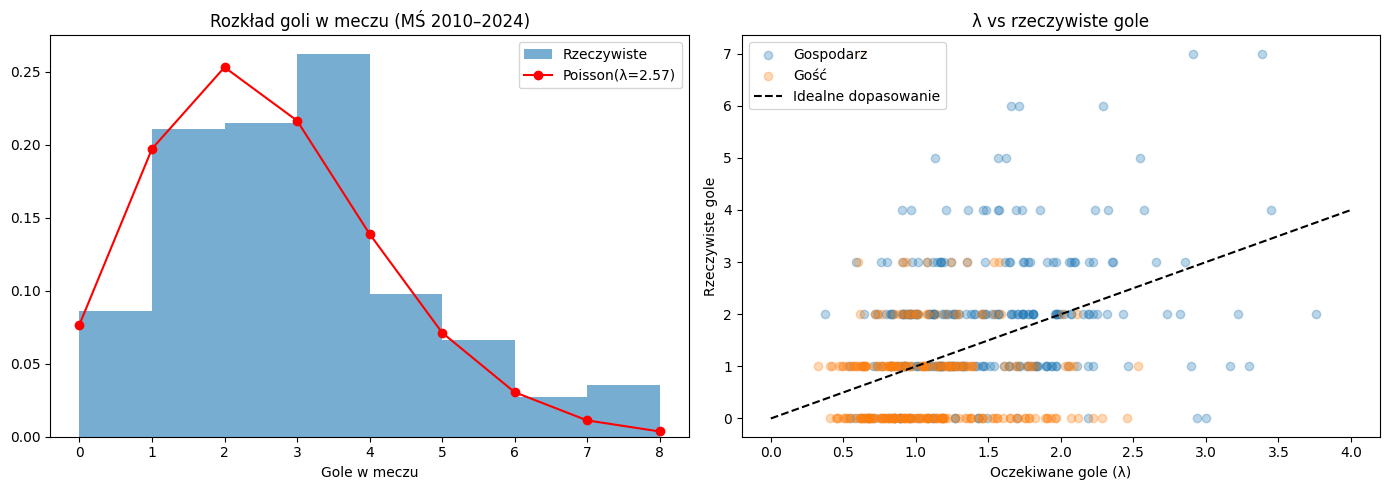

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Lewy: rozkład goli vs Poisson(średnia λ)
mu = df_wc['total_goals'].mean()
k_range = np.arange(0, df_wc['total_goals'].max() + 1)
axes[0].hist(df_wc['total_goals'], bins=k_range, density=True, alpha=0.6, label='Rzeczywiste')
axes[0].plot(k_range, poisson.pmf(k_range, mu), 'r-o', label=f'Poisson(λ={mu:.2f})')
axes[0].set_title('Rozkład goli w meczu (MŚ 2010–2024)')
axes[0].set_xlabel('Gole w meczu')
axes[0].legend()

# Prawy: scatter xG vs rzeczywiste gole
axes[1].scatter(df_wc['exp_h'], df_wc['home_score'], alpha=0.3, label='Gospodarz')
axes[1].scatter(df_wc['exp_a'], df_wc['away_score'], alpha=0.3, label='Gość')
axes[1].plot([0, 4], [0, 4], 'k--', label='Idealne dopasowanie')
axes[1].set_xlabel('Oczekiwane gole (λ)')
axes[1].set_ylabel('Rzeczywiste gole')
axes[1].set_title('λ vs rzeczywiste gole')
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. Symulacja pojedynczego meczu

Dla meczu A vs B losujemy gole z `Poisson(λ)`. W fazie pucharowej remis → dogrywka symulowana jako rzut monetą (uproszczenie).

In [69]:
def simulate_match(code_h, code_a, stats, neutral=True, host_advantage=0.15):
    """
    Symuluje mecz i zwraca (gole_h, gole_a).
    
    neutral=True  → brak premii za boisko (faza grupowa MŚ na ogół tak traktowana)
    host_advantage → mała premia dla gospodarzy turnieju (USA/MEX/CAN)
    """
    att_h = stats[code_h]['att']
    att_a = stats[code_a]['att']
    def_h = stats[code_h]['def']
    def_a = stats[code_a]['def']

    # Lekka premia jeśli drużyna jest gospodarzem turnieju
    c = 1.0
    if code_h in HOST_NATIONS and not neutral:
        c = 1 + host_advantage

    lam_h = att_h * def_a * c
    lam_a = att_a * def_h / c

    # Zabezpieczenie przed ujemnymi λ (przy ekstremalnych parametrach)
    lam_h = max(lam_h, 0.01)
    lam_a = max(lam_a, 0.01)

    return np.random.poisson(lam_h), np.random.poisson(lam_a)


def simulate_knockout_match(code_h, code_a, stats):
    """
    Symuluje mecz pucharowy — remis po 90 min → dogrywka → karne (50/50).
    Zwraca (gole_h, gole_a, zwycięzca_code).
    """
    gh, ga = simulate_match(code_h, code_a, stats, neutral=True)
    if gh == ga:
        # Karne: czyste 50/50 — uproszczenie, można dodać wskaźnik karnych per drużyna
        if np.random.random() < 0.5:
            winner = code_h
        else:
            winner = code_a
    else:
        winner = code_h if gh > ga else code_a
    return gh, ga, winner


# Przykład: Francja vs Argentyna
np.random.seed(0)
results_sample = [simulate_match('FRA', 'ARG', team_stats) for _ in range(10000)]
fra_wins = sum(1 for h, a in results_sample if h > a) / 10000
draws    = sum(1 for h, a in results_sample if h == a) / 10000
arg_wins = sum(1 for h, a in results_sample if h < a) / 10000
print(f"Francja vs Argentyna (10 000 symulacji):")
print(f"  FRA wygrywa: {fra_wins:.1%}")
print(f"  Remis:       {draws:.1%}")
print(f"  ARG wygrywa: {arg_wins:.1%}")

Francja vs Argentyna (10 000 symulacji):
  FRA wygrywa: 25.2%
  Remis:       28.2%
  ARG wygrywa: 46.6%


## 7. Symulacja fazy grupowej

Każda drużyna gra z każdą raz (3 mecze). Tabela: punkty → różnica goli → gole strzelone.

In [70]:
def simulate_group_stage(stats):
    """
    Symuluje całą fazę grupową (wszystkie 12 grup).
    
    Zwraca:
      group_standings: dict {grupa: [(kod, {pts, gf, ga, gd}), ...]} posortowane
      match_results: lista słowników z wynikami wszystkich meczów grupowych
    """
    group_standings = {}
    match_results = []

    for group_name, teams in GROUPS.items():
        # Inicjalizacja tabeli
        table = {t: {'pts': 0, 'gf': 0, 'ga': 0} for t in teams}

        # Każda para gra raz
        for i in range(len(teams)):
            for j in range(i + 1, len(teams)):
                h, a = teams[i], teams[j]
                gh, ga = simulate_match(h, a, stats)

                table[h]['gf'] += gh; table[h]['ga'] += ga
                table[a]['gf'] += ga; table[a]['ga'] += gh

                if gh > ga:
                    table[h]['pts'] += 3
                elif gh == ga:
                    table[h]['pts'] += 1; table[a]['pts'] += 1
                else:
                    table[a]['pts'] += 3

                match_results.append({
                    'group': group_name, 'home': h, 'away': a,
                    'gh': gh, 'ga': ga,
                    'draw': gh == ga,
                })

        # Dodaj różnicę goli i posortuj
        for t in table:
            table[t]['gd'] = table[t]['gf'] - table[t]['ga']

        standings = sorted(
            table.items(),
            key=lambda x: (x[1]['pts'], x[1]['gd'], x[1]['gf']),
            reverse=True
        )
        group_standings[group_name] = standings

    return group_standings, match_results


def get_qualifiers(group_standings):
    """
    Wyłania 32 drużyny do fazy pucharowej:
    - top 2 z każdej z 12 grup (24 drużyny)
    - 8 najlepszych drużyn z 3. miejsc (wg pts → gd → gf)
    """
    top2 = {}        # {grupa: [1. miejsce, 2. miejsce]}
    thirds = []      # lista (kod, stats) wszystkich drużyn z 3. miejsca

    for group, standings in group_standings.items():
        top2[group] = [standings[0][0], standings[1][0]]
        # 3. miejsce
        thirds.append((standings[2][0], standings[2][1]))

    # 8 najlepszych trzecich miejsc
    thirds_sorted = sorted(thirds, key=lambda x: (x[1]['pts'], x[1]['gd'], x[1]['gf']), reverse=True)
    best_thirds = [t[0] for t in thirds_sorted[:8]]

    return top2, best_thirds


# Test jednej symulacji
standings_sample, matches_sample = simulate_group_stage(team_stats)
top2_sample, thirds_sample = get_qualifiers(standings_sample)

print("Przykładowe tabele grupowe (jedna symulacja):")
for g in ['A', 'B', 'C']:
    print(f"\nGrupa {g}:")
    for rank, (code, s) in enumerate(standings_sample[g], 1):
        print(f"  {rank}. {TEAM_NAMES[code]:<20} {s['pts']} pkt  {s['gd']:+d} GD  {s['gf']}:{s['ga']}")

print(f"\nAwans z 3. miejsc: {[TEAM_NAMES[t] for t in thirds_sample]}")

Przykładowe tabele grupowe (jedna symulacja):

Grupa A:
  1. Mexico               5 pkt  +1 GD  1:0
  2. South Africa         4 pkt  +0 GD  4:4
  3. South Korea          3 pkt  +0 GD  3:3
  4. Czechia              2 pkt  -1 GD  2:3

Grupa B:
  1. Switzerland          7 pkt  +5 GD  5:0
  2. Canada               5 pkt  +3 GD  3:0
  3. Bosnia and Herzegovina 4 pkt  +0 GD  3:3
  4. Qatar                0 pkt  -8 GD  2:10

Grupa C:
  1. Scotland             7 pkt  +2 GD  3:1
  2. Brazil               5 pkt  +3 GD  4:1
  3. Haiti                3 pkt  -2 GD  3:5
  4. Morocco              1 pkt  -3 GD  1:4

Awans z 3. miejsc: ['Australia', 'Cape Verde', 'Bosnia and Herzegovina', 'France', 'Ecuador', 'Ghana', 'South Korea', 'Haiti']


## 8. Symulacja fazy pucharowej — oficjalny bracket MŚ 2026

Oficjalne pary R32 (mecze 73–88) zgodnie z losowaniem FIFA (grudzień 2024).

**Schemat:**
- R32 (16 meczów): stałe pary 1. i 2. miejsc + 8 najlepszych 3. miejsc
- R16 → QF → SF → mecz o 3. miejsce + finał

**3. miejsca**: oficjalna tabela FIFA przypisuje 3. drużyny do slotów na podstawie kombinacji grup — uproszczenie: losowe przypisanie do 8 slotów (efekt uśrednia się po 10 000 symulacji).

In [71]:
def simulate_knockout_stage(top2, best_thirds, stats):
    """
    Symuluje fazę pucharową z oficjalnym bracketem MŚ 2026.

    Bracket R32 (mecze 73-88):
      73: 2A-2B    74: 1E-3*   75: 1F-2C   76: 1C-2F
      77: 1I-3*    78: 2E-2I   79: 1A-3*   80: 1L-3*
      81: 1D-3*    82: 1G-3*   83: 2K-2L   84: 1H-2J
      85: 1B-3*    86: 1J-2H   87: 1K-3*   88: 2D-2G
    (*) = najlepsze 3. miejsca, losowo przypisane do slotów
    """
    slot = {}

    for group, (t1, t2) in top2.items():
        slot[f'1{group}'] = t1
        slot[f'2{group}'] = t2

    # 8 najlepszych 3. miejsc losowo do 8 slotów R32
    thirds = list(best_thirds)
    np.random.shuffle(thirds)
    third_slots = [74, 77, 79, 80, 81, 82, 85, 87]
    thirds_map = {m: t for m, t in zip(third_slots, thirds)}

    def play(m, k1, k2):
        t1 = slot[k1] if isinstance(k1, str) else thirds_map[k1]
        t2 = slot[k2] if isinstance(k2, str) else thirds_map[k2]
        gh, ga, winner = simulate_knockout_match(t1, t2, stats)
        slot[f'W{m}'] = winner
        slot[f'L{m}'] = t2 if winner == t1 else t1

    # === R32 ===
    play(73, '2A', '2B');   play(74, '1E', 74);   play(75, '1F', '2C');  play(76, '1C', '2F')
    play(77, '1I', 77);     play(78, '2E', '2I'); play(79, '1A', 79);    play(80, '1L', 80)
    play(81, '1D', 81);     play(82, '1G', 82);   play(83, '2K', '2L'); play(84, '1H', '2J')
    play(85, '1B', 85);     play(86, '1J', '2H'); play(87, '1K', 87);    play(88, '2D', '2G')

    # === R16 ===
    play(89, 'W74', 'W77'); play(90, 'W73', 'W75')
    play(91, 'W76', 'W78'); play(92, 'W79', 'W80')
    play(93, 'W83', 'W84'); play(94, 'W81', 'W82')
    play(95, 'W86', 'W88'); play(96, 'W85', 'W87')

    # === Ćwierćfinały ===
    play(97, 'W89', 'W90'); play(98, 'W93', 'W94')
    play(99, 'W91', 'W92'); play(100, 'W95', 'W96')

    # === Półfinały ===
    play(101, 'W97',  'W98')
    play(102, 'W99',  'W100')

    # === Mecz o 3. miejsce ===
    play(103, 'L101', 'L102')

    # === Finał ===
    play(104, 'W101', 'W102')

    return {
        'qf':        [slot[f'W{m}'] for m in [89,90,91,92,93,94,95,96]],  # 8 ćwierćfinalistów
        'sf':        [slot[f'W{m}'] for m in [97,98,99,100]],              # 4 półfinalistów
        'finalists': (slot['W101'], slot['W102']),
        'third':     slot['W103'],
        'winner':    slot['W104'],
    }


# Test jednej symulacji
standings_sample, matches_sample = simulate_group_stage(team_stats)
top2_sample, thirds_sample = get_qualifiers(standings_sample)
ko = simulate_knockout_stage(top2_sample, thirds_sample, team_stats)
f1, f2 = ko['finalists']
print(f"Finał:       {TEAM_NAMES[f1]} vs {TEAM_NAMES[f2]}")
print(f"Zwycięzca:   {TEAM_NAMES[ko['winner']]}")
print(f"3. miejsce:  {TEAM_NAMES[ko['third']]}")
print(f"Półfinaliści: {[TEAM_NAMES[t] for t in ko['sf']]}")

Finał:       Spain vs Mexico
Zwycięzca:   Spain
3. miejsce:  Argentina
Półfinaliści: ['Netherlands', 'Spain', 'Mexico', 'Argentina']


## 9. Zdarzenia losowe: czerwone kartki i bramki samobójcze

Dla pytań specjalnych typera:
- **Pierwsza czerwona kartka** — która drużyna jako pierwsza dostanie czerwoną kartkę?
- **Ile bramek samobójczych** — liczymy z historycznych danych MŚ

Każdy mecz to niezależna próba Bernoulliego z prawdopodobieństwem `p`.

In [72]:
# Źródło: sportshistori.com / Wikipedia + goalscorers.csv — MŚ 2010–2022
P_RED_CARD_PER_MATCH = 0.141   # 0.141 — kalibrowane z danych
P_OWN_GOAL_PER_MATCH = 0.082   # 0.082 — kalibrowane z danych

RED_CARD_FACTOR = None


def simulate_red_cards_and_og(match_results, p_red=P_RED_CARD_PER_MATCH, p_og=P_OWN_GOAL_PER_MATCH):
    """
    Dla każdego meczu grupowego symuluje czerwone kartki i bramki samobójcze.
    Zwraca: first_red_team, total_own_goals
    """
    first_red_team = None
    total_own_goals = 0

    for match in match_results:
        if first_red_team is None and np.random.random() < p_red:
            team_h, team_a = match['home'], match['away']
            if RED_CARD_FACTOR:
                w_h = RED_CARD_FACTOR.get(team_h, 1.0)
                w_a = RED_CARD_FACTOR.get(team_a, 1.0)
                first_red_team = team_h if np.random.random() < w_h / (w_h + w_a) else team_a
            else:
                first_red_team = team_h if np.random.random() < 0.5 else team_a

        total_own_goals += np.random.poisson(p_og)

    return first_red_team, total_own_goals


red, og = simulate_red_cards_and_og(matches_sample)
print(f"Pierwsza czerwona kartka: {TEAM_NAMES.get(red, 'brak')}")
print(f"Samoboje w fazie grupowej: {og}")
print(f"P_RED_CARD_PER_MATCH = {P_RED_CARD_PER_MATCH:.4f}")
print(f"P_OWN_GOAL_PER_MATCH = {P_OWN_GOAL_PER_MATCH:.4f}")

Pierwsza czerwona kartka: Canada
Samoboje w fazie grupowej: 5
P_RED_CARD_PER_MATCH = 0.1410
P_OWN_GOAL_PER_MATCH = 0.0820


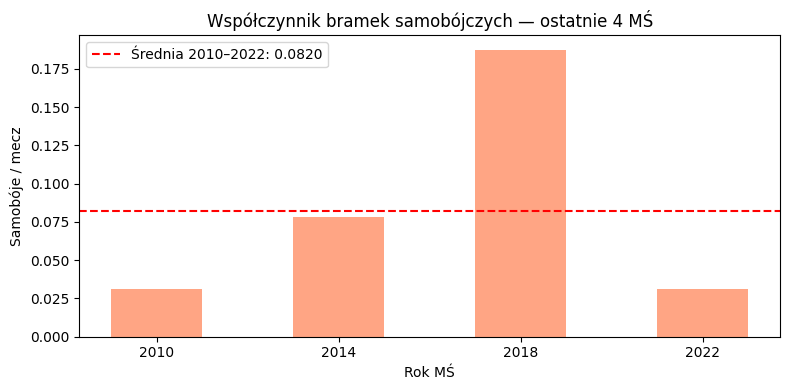

      matches  own_goals  og_per_match
year                                  
2010       64          2      0.031250
2014       64          5      0.078125
2018       64         12      0.187500
2022       64          2      0.031250

Używamy P_OWN_GOAL_PER_MATCH = 0.0820 (kalibrowane na MŚ 2010–2022)


In [73]:
# Kalibracja współczynnika bramek samobójczych z danych goalscorers.csv
gs = pd.read_csv('data/goalscorers.csv')
gs['date'] = pd.to_datetime(gs['date'])

df_wc_dates = df[(df['tournament'] == 'World Cup') & (df['date'].dt.year.isin([2010,2014,2018,2022]))]['date']
gs_wc = gs[gs['date'].isin(df_wc_dates)].copy()
gs_wc['year'] = gs_wc['date'].dt.year

wc_og = gs_wc.groupby('year').agg(goals=('own_goal','count'), own_goals=('own_goal','sum'))
wc_og['matches'] = 64
wc_og['og_per_match'] = wc_og['own_goals'] / wc_og['matches']

P_OWN_GOAL_CALIBRATED = wc_og['own_goals'].sum() / wc_og['matches'].sum()

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(wc_og.index, wc_og['og_per_match'], color='coral', alpha=0.7, width=2)
ax.axhline(P_OWN_GOAL_CALIBRATED, color='red', linestyle='--', linewidth=1.5,
           label=f'Średnia 2010–2022: {P_OWN_GOAL_CALIBRATED:.4f}')
ax.set_xlabel('Rok MŚ')
ax.set_ylabel('Samobóje / mecz')
ax.set_title('Współczynnik bramek samobójczych — ostatnie 4 MŚ')
ax.set_xticks([2010, 2014, 2018, 2022])
ax.legend()
plt.tight_layout()
plt.show()

print(wc_og[['matches', 'own_goals', 'og_per_match']].to_string())
print(f"\nUżywamy P_OWN_GOAL_PER_MATCH = {P_OWN_GOAL_CALIBRATED:.4f} (kalibrowane na MŚ 2010–2022)")

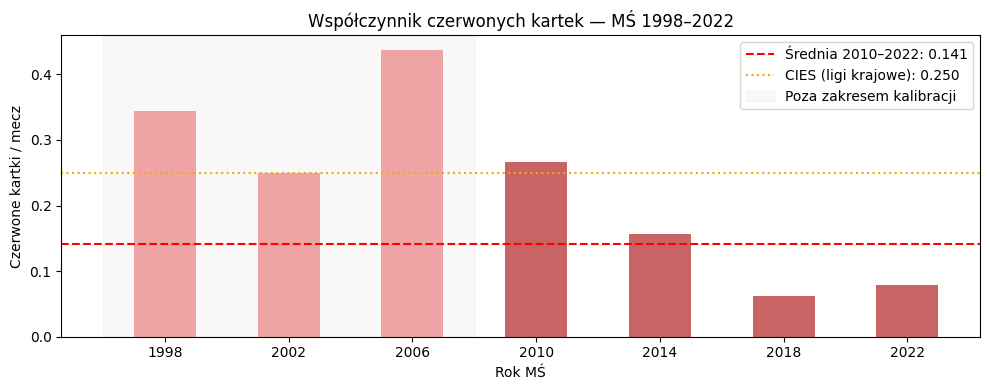

 year  matches  red_cards  rc_per_match
 1998       64         22      0.343750
 2002       64         16      0.250000
 2006       64         28      0.437500
 2010       64         17      0.265625
 2014       64         10      0.156250
 2018       64          4      0.062500
 2022       64          5      0.078125

Kalibracja (2010–2022): 36 kartek w 256 meczach
Używamy P_RED_CARD_PER_MATCH = 0.1406


In [74]:
# Kalibracja współczynnika czerwonych kartek
# Źródło: sportshistori.com + planetworldcup.com — MŚ 1998–2022
# Używamy od 2010: wyraźny trend spadkowy po 2006 (VAR, zmiana przepisów)
red_cards_wc = pd.DataFrame({
    'year':      [1998, 2002, 2006, 2010, 2014, 2018, 2022],
    'matches':   [64,   64,   64,   64,   64,   64,   64],
    'red_cards': [22,   16,   28,   17,   10,   4,    5],
})
red_cards_wc['rc_per_match'] = red_cards_wc['red_cards'] / red_cards_wc['matches']

modern = red_cards_wc[red_cards_wc['year'] >= 2010]
P_RED_CARD_CALIBRATED = modern['red_cards'].sum() / modern['matches'].sum()

fig, ax = plt.subplots(figsize=(10, 4))
colors = ['lightcoral' if y < 2010 else 'firebrick' for y in red_cards_wc['year']]
ax.bar(red_cards_wc['year'], red_cards_wc['rc_per_match'], color=colors, alpha=0.7, width=2)
ax.axhline(P_RED_CARD_CALIBRATED, color='red', linestyle='--', linewidth=1.5,
           label=f'Średnia 2010–2022: {P_RED_CARD_CALIBRATED:.3f}')
ax.axhline(0.25, color='orange', linestyle=':', linewidth=1.5,
           label='CIES (ligi krajowe): 0.250')
ax.axvspan(1996, 2008, alpha=0.05, color='gray', label='Poza zakresem kalibracji')
ax.set_xlabel('Rok MŚ')
ax.set_ylabel('Czerwone kartki / mecz')
ax.set_title('Współczynnik czerwonych kartek — MŚ 1998–2022')
ax.set_xticks(red_cards_wc['year'])
ax.legend()
plt.tight_layout()
plt.show()

print(red_cards_wc.to_string(index=False))
print(f"\nKalibracja (2010–2022): {modern['red_cards'].sum()} kartek w {modern['matches'].sum()} meczach")
print(f"Używamy P_RED_CARD_PER_MATCH = {P_RED_CARD_CALIBRATED:.4f}")

## 10. Monte Carlo — 10 000 symulacji

Zbieramy wyniki każdej symulacji i obliczamy częstości jako estymaty prawdopodobieństwa.

In [75]:
from collections import Counter

# Liczniki
wins_tournament  = Counter()  # P(wygrana turnieju)
third_place      = Counter()  # P(3. miejsce)
finalist_count   = Counter()  # P(finalista)
top4_count       = Counter()  # P(półfinał)
top8_count       = Counter()  # P(ćwierćfinał)
group_winner     = Counter()  # P(wygranie grupy)
group_qualify    = Counter()  # P(awans z grupy)
third_advance    = Counter()  # P(awans z 3. miejsca)
most_goals_group = Counter()
first_red_card   = Counter()
own_goals_dist   = Counter()
draws_dist       = Counter()

print(f"Uruchamiam {N_SIMULATIONS:,} symulacji...")

for sim in range(N_SIMULATIONS):
    # --- Faza grupowa ---
    group_standings, match_results = simulate_group_stage(team_stats)
    top2, best_thirds = get_qualifiers(group_standings)

    group_goals = Counter()
    draws_this_sim = 0
    for match in match_results:
        group_goals[match['home']] += match['gh']
        group_goals[match['away']] += match['ga']
        if match['draw']:
            draws_this_sim += 1

    draws_dist[draws_this_sim] += 1
    most_goals_group[max(group_goals, key=group_goals.get)] += 1

    for group, standings in group_standings.items():
        group_winner[standings[0][0]] += 1
        group_qualify[standings[0][0]] += 1
        group_qualify[standings[1][0]] += 1

    for code in best_thirds:
        third_advance[code] += 1

    red_team, n_og = simulate_red_cards_and_og(match_results)
    if red_team:
        first_red_card[red_team] += 1
    own_goals_dist[n_og] += 1

    # --- Faza pucharowa ---
    ko = simulate_knockout_stage(top2, best_thirds, team_stats)

    for code in ko['qf']:
        top8_count[code] += 1
    for code in ko['sf']:
        top4_count[code] += 1
    for code in ko['finalists']:
        finalist_count[code] += 1
    third_place[ko['third']] += 1
    wins_tournament[ko['winner']] += 1

    if (sim + 1) % 2000 == 0:
        print(f"  {sim+1:,} / {N_SIMULATIONS:,}")

print("✓ Gotowe")

Uruchamiam 10,000 symulacji...
  2,000 / 10,000
  4,000 / 10,000
  6,000 / 10,000
  8,000 / 10,000
  10,000 / 10,000
✓ Gotowe


## 11. Wyniki — P(wygrana turnieju) i P(finalista)

In [76]:
def to_prob_df(counter, label='P', top_n=16):
    """Zamienia Counter na DataFrame z prawdopodobieństwami."""
    df_out = pd.DataFrame(counter.most_common(top_n), columns=['code', 'count'])
    df_out[label] = df_out['count'] / N_SIMULATIONS
    df_out['name'] = df_out['code'].map(TEAM_NAMES)
    return df_out[['name', label]]


df_win = to_prob_df(wins_tournament, 'P(wygrana)', top_n=16)
df_fin = to_prob_df(finalist_count, 'P(finalista)', top_n=16)
df_top8 = to_prob_df(top8_count, 'P(top 8)', top_n=16)

summary = df_win.merge(df_fin, on='name').merge(df_top8, on='name')
print("Top 16 drużyn — prawdopodobieństwa:")
print(summary.to_string(index=False))

Top 16 drużyn — prawdopodobieństwa:
       name  P(wygrana)  P(finalista)  P(top 8)
     Brazil      0.1477        0.2290    0.5347
  Argentina      0.1379        0.2149    0.4789
      Spain      0.1190        0.2052    0.4420
   Colombia      0.0717        0.1378    0.4079
    England      0.0630        0.1217    0.4114
   Portugal      0.0627        0.1248    0.3875
     France      0.0601        0.1197    0.3730
    Uruguay      0.0492        0.0937    0.2926
    Belgium      0.0360        0.0818    0.3522
Netherlands      0.0337        0.0751    0.3041
    Germany      0.0305        0.0680    0.2834
    Ecuador      0.0260        0.0608    0.2618
    Senegal      0.0253        0.0599    0.2427
    Croatia      0.0184        0.0472    0.2315
Switzerland      0.0176        0.0416    0.2465
    Morocco      0.0175        0.0468    0.2458


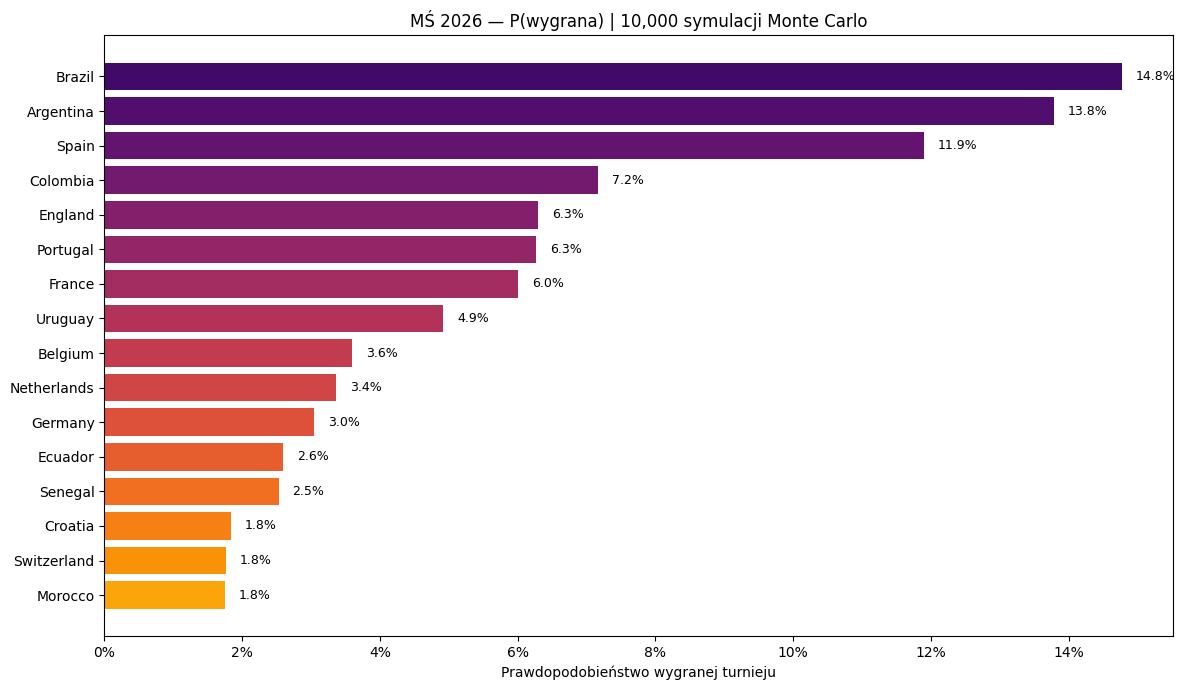

In [77]:
# Wykres P(wygrana turnieju)
top16 = pd.DataFrame(wins_tournament.most_common(16), columns=['code', 'wins'])
top16['prob'] = top16['wins'] / N_SIMULATIONS
top16['name'] = top16['code'].map(TEAM_NAMES)

cmap = plt.cm.inferno
colors = cmap(np.linspace(0.8, 0.2, len(top16)))

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(top16['name'][::-1], top16['prob'][::-1], color=colors)
for bar in bars:
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f"{bar.get_width():.1%}", va='center', fontsize=9)
ax.set_xlabel('Prawdopodobieństwo wygranej turnieju')
ax.set_title(f'MŚ 2026 — P(wygrana) | {N_SIMULATIONS:,} symulacji Monte Carlo')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
plt.tight_layout()
plt.show()

## 12. Wyniki — zakłady dodatkowe

Dla każdego pytania specjalnego: rozkład prawdopodobieństwa możliwych odpowiedzi.

In [78]:
# --- Finalista (dowolna z dwóch drużyn) ---
print("P(drużyna X dotrze do finału):")
df_fin_full = to_prob_df(finalist_count, 'P(finalista)', top_n=20)
print(df_fin_full.to_string(index=False))

P(drużyna X dotrze do finału):
       name  P(finalista)
     Brazil        0.2290
  Argentina        0.2149
      Spain        0.2052
   Colombia        0.1378
   Portugal        0.1248
    England        0.1217
     France        0.1197
    Uruguay        0.0937
    Belgium        0.0818
Netherlands        0.0751
    Germany        0.0680
    Ecuador        0.0608
    Senegal        0.0599
    Croatia        0.0472
    Morocco        0.0468
Switzerland        0.0416
     Mexico        0.0261
   Paraguay        0.0243
     Norway        0.0209
      Egypt        0.0180


In [79]:
# --- Awans z 3. miejsca ---
print("P(drużyna X awansuje z 3. miejsca w grupie):")
df_third = to_prob_df(third_advance, 'P(3. miejsce → awans)', top_n=20)
print(df_third.to_string(index=False))

P(drużyna X awansuje z 3. miejsca w grupie):
                  name  P(3. miejsce → awans)
           Ivory Coast                 0.3634
              Scotland                 0.3072
Bosnia and Herzegovina                 0.2739
                Norway                 0.2668
               Austria                 0.2487
              DR Congo                 0.2384
                 Ghana                 0.2379
                  Iran                 0.2292
               Algeria                 0.2274
                 Egypt                 0.2180
            Cape Verde                 0.2125
           South Korea                 0.2054
                Sweden                 0.2047
               Ecuador                 0.2030
                 Japan                 0.2018
             Australia                 0.1997
               Senegal                 0.1982
               Tunisia                 0.1979
               Czechia                 0.1957
                Turkey             

In [80]:
# --- Najwięcej bramek w fazie grupowej ---
print("P(drużyna X zdobędzie najwięcej goli w fazie grupowej):")
df_goals = to_prob_df(most_goals_group, 'P(top gole)', top_n=16)
print(df_goals.to_string(index=False))

P(drużyna X zdobędzie najwięcej goli w fazie grupowej):
       name  P(top gole)
     Brazil       0.1886
Switzerland       0.1200
    Germany       0.1148
  Argentina       0.1106
      Spain       0.0973
    England       0.0385
    Belgium       0.0373
Netherlands       0.0322
     France       0.0295
    Ecuador       0.0262
     Canada       0.0258
   Portugal       0.0192
   Colombia       0.0172
    Uruguay       0.0150
     Turkey       0.0147
     Mexico       0.0147


In [81]:
# --- Pierwsza czerwona kartka ---
print("P(drużyna X dostanie pierwszą czerwoną kartkę w turnieju):")
# Normalizujemy po symulacjach gdzie w ogóle padła czerwona kartka
total_red_sims = sum(first_red_card.values())
df_red = pd.DataFrame(first_red_card.most_common(16), columns=['code', 'count'])
df_red['P(pierwsza czerwona)'] = df_red['count'] / total_red_sims
df_red['name'] = df_red['code'].map(TEAM_NAMES)
print(df_red[['name', 'P(pierwsza czerwona)']].head(12).to_string(index=False))
print(f"\n(Procent symulacji bez czerwonej kartki: {(N_SIMULATIONS - total_red_sims)/N_SIMULATIONS:.1%})")

P(drużyna X dostanie pierwszą czerwoną kartkę w turnieju):
                  name  P(pierwsza czerwona)
                Mexico                0.1850
          South Africa                0.1570
           South Korea                0.1349
               Czechia                0.1215
                Canada                0.0713
           Switzerland                0.0659
                 Qatar                0.0573
Bosnia and Herzegovina                0.0493
                Brazil                0.0304
              Scotland                0.0227
                 Haiti                0.0211
               Morocco                0.0206

(Procent symulacji bez czerwonej kartki: 0.0%)


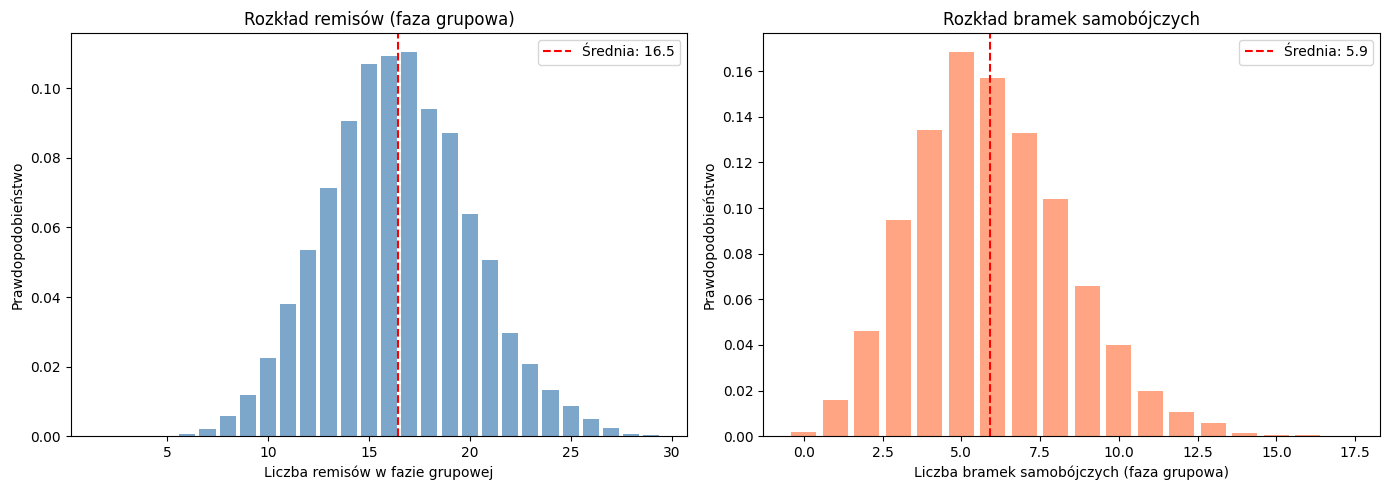

Najprawdopodobniejsza liczba remisów: 17
Najprawdopodobniejsza liczba samobójów: 5


In [82]:
# --- Rozkład remisów w fazie grupowej ---
draws_total = sum(draws_dist.values())
draws_prob = {k: v / draws_total for k, v in sorted(draws_dist.items())}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Remisy
axes[0].bar(list(draws_prob.keys()), list(draws_prob.values()), color='steelblue', alpha=0.7)
axes[0].axvline(x=np.mean(list(draws_dist.elements())), color='red', linestyle='--',
                label=f"Średnia: {np.mean(list(draws_dist.elements())):.1f}")
axes[0].set_xlabel('Liczba remisów w fazie grupowej')
axes[0].set_ylabel('Prawdopodobieństwo')
axes[0].set_title('Rozkład remisów (faza grupowa)')
axes[0].legend()

# Samoboje
og_prob = {k: v / N_SIMULATIONS for k, v in sorted(own_goals_dist.items())}
axes[1].bar(list(og_prob.keys()), list(og_prob.values()), color='coral', alpha=0.7)
axes[1].axvline(x=np.mean(list(own_goals_dist.elements())), color='red', linestyle='--',
                label=f"Średnia: {np.mean(list(own_goals_dist.elements())):.1f}")
axes[1].set_xlabel('Liczba bramek samobójczych (faza grupowa)')
axes[1].set_ylabel('Prawdopodobieństwo')
axes[1].set_title('Rozkład bramek samobójczych')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Najprawdopodobniejsza liczba remisów: {max(draws_prob, key=draws_prob.get)}")
print(f"Najprawdopodobniejsza liczba samobójów: {max(og_prob, key=og_prob.get)}")

## 13. Krol strzeleow / asystentow — model (dane 2025/26)

Model oparty na **rzeczywistych bramkach/asystach** w sezonie 2025/26 (football-data.org, top 50 per liga),
wazonych **jakoscia ligi** (Opta Power Rankings, czerwiec 2025).

**Formula:**


**Opta Power Rankings (srednia 5 lig = 87.68):**

| Liga | Score | Factor |
|------|-------|--------|
| PL   | 92.6  | 1.056  |
| SA   | 87.0  | 0.992  |
| PD   | 87.0  | 0.992  |
| BL1  | 86.3  | 0.984  |
| FL1  | 85.5  | 0.975  |

Dane:  (pobrane 13 maja 2026).
Zasieg: PL + BL1 + SA + PD + FL1. Zawodnicy spoza tych lig (np. brazylijscy, tureccy) nie sa objeci.
Kady: nie wymagane — zakladamy, ze top strzelcy z WC 2026 beda powolani.

In [83]:
import json

# --- Opta Power Rankings (czerwiec 2025) ---
OPTA = {'PL': 92.6, 'BL1': 86.3, 'SA': 87.0, 'PD': 87.0, 'FL1': 85.5}
_avg_opta = sum(OPTA.values()) / len(OPTA)
LEAGUE_FACTOR = {code: v / _avg_opta for code, v in OPTA.items()}

# --- Mapa: nationality (football-data.org) -> kod WC 2026 ---
NAT_TO_CODE = {
    'England':                 'ENG', 'Norway':           'NOR', 'France':    'FRA',
    'Brazil':                  'BRA', 'Germany':          'GER', 'Argentina': 'ARG',
    'Spain':                   'ESP', 'Colombia':         'COL', 'Sweden':    'SWE',
    'Portugal':                'POR', 'Croatia':          'CRO', 'Czech Republic': 'CZE',
    'Ghana':                   'GHA', 'Belgium':          'BEL', 'Tunisia':   'TUN',
    'Netherlands':             'NED', 'Japan':            'JPN', 'South Korea': 'KOR',
    'Mexico':                  'MEX', 'Ecuador':          'ECU', 'Uruguay':   'URY',
    'Switzerland':             'SUI', 'Canada':           'CAN', 'Australia': 'AUS',
    'Turkey':                  'TUR', 'Austria':          'AUT', 'Senegal':   'SEN',
    'Egypt':                   'EGY', 'Iran':             'IRN', 'Morocco':   'MAR',
    'South Africa':            'RSA', 'Qatar':            'QAT', 'Paraguay':  'PAR',
    'Scotland':                'SCO', 'Algeria':          'ALG', 'Jordan':    'JOR',
    'New Zealand':             'NZL', 'Saudi Arabia':     'KSA', 'Iraq':      'IRQ',
    'Cape Verde':              'CPV', 'Uzbekistan':       'UZB', 'DR Congo':  'COD',
    'Cura\u00e7ao':           'CUR', 'Haiti':            'HAI', 'Panama':    'PAN',
    'Ivory Coast':             'CIV', "C\u00f4te d'Ivoire": 'CIV',
    'Bosnia and Herzegovina':  'BIH',
}

WC26_CODES = set(ALL_TEAMS)

# --- Wczytaj dane strzelcow/asystentow (football-data.org, sezon 2025/26) ---
SCORERS_JSON = r'C:\Users\barto\Downloads\scorers_2025.json'
with open(SCORERS_JSON, encoding='utf-8') as f:
    raw = json.load(f)

players = {}  # player_id -> dict

for league_code, scorers in raw.items():
    lf = LEAGUE_FACTOR.get(league_code, 1.0)
    for s in scorers:
        nat = s['player'].get('nationality', '')
        wc_code = NAT_TO_CODE.get(nat)
        if wc_code not in WC26_CODES:
            continue
        pid    = s['player']['id']
        goals   = s.get('goals') or 0
        assists = s.get('assists') or 0
        played  = max(s.get('playedMatches') or 1, 1)
        adj_g   = goals   / played * lf
        adj_a   = assists / played * lf
        if pid not in players or goals > players[pid]['goals']:
            players[pid] = {
                'name':    s['player']['name'],
                'nat':     nat,
                'team':    wc_code,
                'league':  league_code,
                'goals':   goals,
                'assists': assists,
                'played':  played,
                'adj_g90': adj_g,
                'adj_a90': adj_a,
            }

print(f"Zawodnicy z WC 2026 w danych: {len(players)}")

# --- E[mecze w turnieju] dla kazdej druzyny (z MC) ---
def exp_matches(code):
    N = N_SIMULATIONS
    p_r32 = group_qualify.get(code, 0) / N   # awans z grupy -> gra R32
    p_qf  = top8_count.get(code, 0)   / N   # cwierc
    p_sf  = top4_count.get(code, 0)   / N   # polfinalist
    p_fin = finalist_count.get(code, 0) / N  # finalista
    # R16 — brak dedykowanego licznika; srednia arytmetyczna R32 i QF
    p_r16 = (p_r32 + p_qf) / 2
    # wszyscy polfinalisci graja jeszcze jeden mecz (final lub o 3. miejsce)
    return 3 + p_r32 + p_r16 + p_qf + p_sf + p_fin

for p in players.values():
    em = exp_matches(p['team'])
    p['exp_matches'] = em
    p['exp_goals']   = p['adj_g90'] * em
    p['exp_assists'] = p['adj_a90'] * em

# --- TOP 20 KROL STRZELEOW ---
top_scorers  = sorted(players.values(), key=lambda x: x['exp_goals'],   reverse=True)[:20]
top_assisters = sorted(players.values(), key=lambda x: x['exp_assists'], reverse=True)[:20]
total_g = sum(p['exp_goals']   for p in top_scorers)
total_a = sum(p['exp_assists'] for p in top_assisters)

print("\nTop 20 kandydatow na krola strzeleow MS 2026:")
print(f"{'Zawodnik':<28} {'Kraj':<5} {'Liga':<4} {'G':>4} {'G/M':>5} {'LF':>5} {'E[M]':>5} {'E[G]':>5} {'P%':>6}")
print("-" * 78)
for p in top_scorers:
    pct = p['exp_goals'] / total_g * 100
    print(f"{p['name']:<28} {p['team']:<5} {p['league']:<4} {p['goals']:>4} "
          f"{p['goals']/p['played']:>5.2f} {LEAGUE_FACTOR[p['league']]:>5.3f} "
          f"{p['exp_matches']:>5.2f} {p['exp_goals']:>5.3f} {pct:>5.1f}%")

print(f"\nTop 20 kandydatow na krola asystentow MS 2026:")
print(f"{'Zawodnik':<28} {'Kraj':<5} {'Liga':<4} {'A':>4} {'A/M':>5} {'E[A]':>5} {'P%':>6}")
print("-" * 63)
for p in top_assisters:
    pct = p['exp_assists'] / total_a * 100
    print(f"{p['name']:<28} {p['team']:<5} {p['league']:<4} {p['assists']:>4} "
          f"{p['assists']/p['played']:>5.2f} {p['exp_assists']:>5.3f} {pct:>5.1f}%")


Zawodnicy z WC 2026 w danych: 192

Top 20 kandydatow na krola strzeleow MS 2026:
Zawodnik                     Kraj  Liga    G   G/M    LF  E[M]  E[G]     P%
------------------------------------------------------------------------------
Harry Kane                   ENG   BL1    33  1.06 0.984  5.29 5.541   8.9%
Kylian Mbappé                FRA   PD     24  0.86 0.992  5.12 4.354   7.0%
Donyell Malen                NED   SA     13  0.81 0.992  4.83 3.896   6.3%
Thiago Rodrigues             BRA   PL     22  0.61 1.056  5.83 3.765   6.0%
Joaquín Panichelli           ARG   FL1    16  0.59 0.975  5.68 3.280   5.3%
Deniz Undav                  GER   BL1    19  0.68 0.984  4.84 3.233   5.2%
Erling Haaland               NOR   PL     26  0.76 1.056  3.97 3.209   5.2%
Lamine Yamal                 ESP   PD     16  0.57 0.992  5.59 3.172   5.1%
Lautaro Martínez             ARG   SA     17  0.55 0.992  5.68 3.088   5.0%
Esteban Lepaul               FRA   FL1    20  0.61 0.975  5.12 3.026   4.9%
Raph

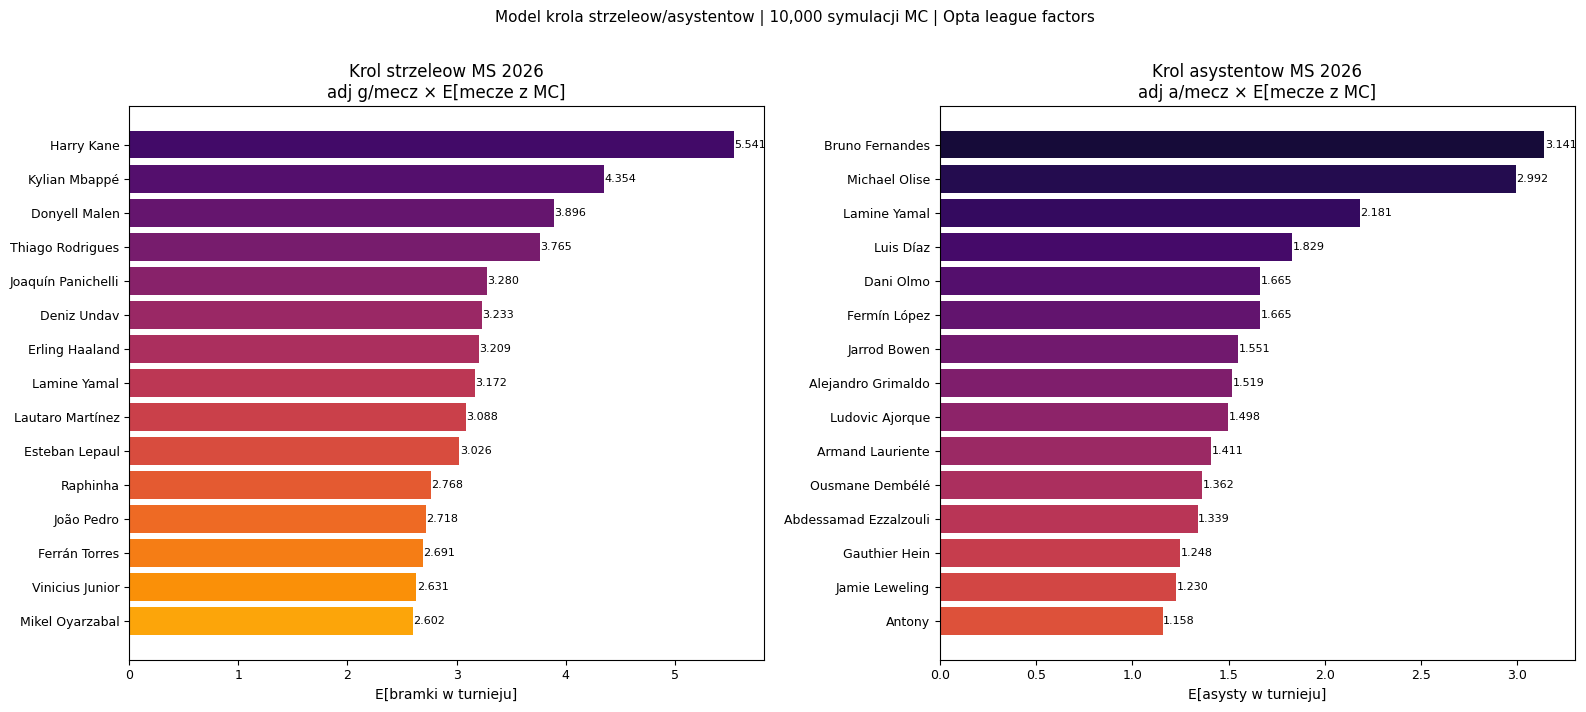


Uwaga: model obejmuje zawodnikow z PL/BL1/SA/PD/FL1.
Zawodnicy spoza top 5 europejskich lig nie sa uwzglednieni.


In [84]:
# --- Wykres: kandydaci na krola strzeleow i asystentow ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
cmap = plt.cm.inferno

names_g  = [p['name'] for p in top_scorers[:15]][::-1]
scores_g = [p['exp_goals'] for p in top_scorers[:15]][::-1]
colors_g = cmap(np.linspace(0.8, 0.2, len(names_g)))
bars1 = ax1.barh(names_g, scores_g, color=colors_g)
for bar in bars1:
    ax1.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
             f"{bar.get_width():.3f}", va='center', fontsize=8)
ax1.set_xlabel('E[bramki w turnieju]')
ax1.set_title('Krol strzeleow MS 2026\nadj g/mecz \u00d7 E[mecze z MC]')
ax1.tick_params(labelsize=9)

names_a  = [p['name'] for p in top_assisters[:15]][::-1]
scores_a = [p['exp_assists'] for p in top_assisters[:15]][::-1]
colors_a = cmap(np.linspace(0.6, 0.1, len(names_a)))
bars2 = ax2.barh(names_a, scores_a, color=colors_a)
for bar in bars2:
    ax2.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
             f"{bar.get_width():.3f}", va='center', fontsize=8)
ax2.set_xlabel('E[asysty w turnieju]')
ax2.set_title('Krol asystentow MS 2026\nadj a/mecz \u00d7 E[mecze z MC]')
ax2.tick_params(labelsize=9)

plt.suptitle(f'Model krola strzeleow/asystentow | {N_SIMULATIONS:,} symulacji MC | Opta league factors',
             fontsize=11, y=1.01)
plt.tight_layout()
plt.show()
print("\nUwaga: model obejmuje zawodnikow z PL/BL1/SA/PD/FL1.")
print("Zawodnicy spoza top 5 europejskich lig nie sa uwzglednieni.")


## 14. Podsumowanie — co model daje aplikacji

Dla każdego pytania specjalnego w typerze, model produkuje:

| Pytanie | Output modelu |
|---|---|
| Finalista | `P(team X reaches final)` — słownik per drużyna |
| Awans z 3. miejsca | `P(team X advances as 3rd)` |
| Najwięcej goli w grupie | `P(team X scores most in group stage)` |
| Pierwsza czerwona kartka | `P(team X gets first red card)` |
| Bramki samobójcze | rozkład `P(n own goals)` — porównujemy z typem gracza |
| Remisy w grupie | rozkład `P(n draws)` — z symulacji, nie osobnego modelu |
| Król strzelców | `P(player X)` — osobny model po powołaniach |

Dla **P(wygrana typera)**: dla każdego uczestnika typera sumujemy:
- aktualne punkty
- sample z rozkładu punktów meczowych (dane z Euro)
- sample z `Bernoulli(P(ich typ jest poprawny))` dla każdego zakładu specjalnego

→ kto ma najwyższy łączny wynik → ten 'wygrywa' symulację → liczymy po 10 000 iteracji.

## TODO przed wdrożeniem

- [ ] Zaciągnąć rozkład {0, 1, 3} z danych z Euro (Twój plik)
- [ ] Zaimplementować oficjalny bracket R32 (A1 vs B2 etc.)
- [ ] Po 12 maja: powołania → xG/xA → `estimate_top_scorer_prob()`
- [ ] Przenieść do `analytics/` jako Django app z modelem `SimulationResult`
- [ ] Cron: odpalić symulację po każdym zakończonym meczu (`apply_match_results` → trigger)

## 15. Symulacja typerów — model herdingu

**Cel:** oszacować oczekiwany rozkład punktów na koniec turnieju i zwalidować model na danych Euro 2024.

**Model herdingu (skalibrowany na Euro 2024, n=2550 zakładów):**
- ~33% graczy obstawia ten sam „modalny" wynik z D-C (efekt stadny)
- pozostałe 67% losuje swój typ niezależnie z Poissona(λ_h, λ_a)
- dropout rośnie w kolejnych rundach: 8% (GS) → 21% (R16) → 27% (QF/SF/F)

**Backtest:** porównujemy symulowany rozkład punktów 50 graczy z rzeczywistą tabelą Euro 2024.

In [85]:
import openpyxl
from scipy.stats import poisson as sp_poisson

# --- Parametry modelu typerów (kalibrowane na Euro 2024) ---
HERDING_RATE = 0.33   # mediana % graczy na modalny wynik (Euro 2024: 33%)
DROPOUT_GS   = 0.08   # blank bets faza grupowa
DROPOUT_R16  = 0.21   # blank bets R16 / R32
DROPOUT_KO   = 0.27   # blank bets QF / SF / Final

N_TYPERS     = 50
N_TYPER_SIMS = 5_000

# Polskie nazwy z xlsx → kody 3-literowe
EURO2024_CODE_MAP = {
    'NIEMCY': 'GER',  'SZKOCJA': 'SCO',   'WĘGRY': 'HUN',  'SZWAJCARIA': 'SUI',
    'HISZPANIA': 'ESP','CHORWACJA': 'CRO', 'WŁOCHY': 'ITA', 'ALBANIA': 'ALB',
    'POLSKA': 'POL',  'HOLANDIA': 'NED',  'SŁOWENIA': 'SVN','DANIA': 'DEN',
    'SERBIA': 'SRB',  'ANGLIA': 'ENG',    'RUMUNIA': 'ROU', 'UKRAINA': 'UKR',
    'BELGIA': 'BEL',  'SŁOWACJA': 'SVK',  'AUSTRIA': 'AUT', 'FRANCJA': 'FRA',
    'TURCJA': 'TUR',  'PORTUGALIA': 'POR','CZECHY': 'CZE',  'GRUZJA': 'GEO',
}

DROPOUT_BY_PHASE = {'GS': DROPOUT_GS, 'R16': DROPOUT_R16,
                    'QF': DROPOUT_KO,  'SF': DROPOUT_KO, 'F': DROPOUT_KO}


def get_lams(code_h, code_a):
    """λ_h i λ_a z D-C; fallback na avg dla drużyn spoza MŚ 2026."""
    if code_h in team_stats and code_a in team_stats:
        lh = team_stats[code_h]['att'] * team_stats[code_a]['def']
        la = team_stats[code_a]['att'] * team_stats[code_h]['def']
    else:
        avg = np.mean([s['att'] for s in team_stats.values()])
        lh = la = avg * avg
    return max(lh, 0.01), max(la, 0.01)


def modal_score(lam_h, lam_a, max_g=8):
    """Najczęstszy wynik z Poissona(λ_h, λ_a)."""
    probs = np.outer(
        sp_poisson.pmf(np.arange(max_g + 1), lam_h),
        sp_poisson.pmf(np.arange(max_g + 1), lam_a),
    )
    idx = np.unravel_index(np.argmax(probs), probs.shape)
    return int(idx[0]), int(idx[1])


def simulate_match_bets(lam_h, lam_a, ah, aa, n_players,
                        h_rate=HERDING_RATE, dropout=0.0):
    """
    Symuluje zakłady n_players dla jednego meczu.
    h_rate: P(gracz obstawia modalny wynik) — efekt stadny.
    dropout: P(gracz nie obstawia) → 0 pkt.
    Zwraca array punktów (n_players,).
    """
    mh, ma = modal_score(lam_h, lam_a)
    active = np.random.random(n_players) >= dropout
    herds  = np.random.random(n_players) < h_rate

    bet_h = np.where(herds, mh, np.random.poisson(lam_h, n_players)).astype(int)
    bet_a = np.where(herds, ma, np.random.poisson(lam_a, n_players)).astype(int)

    exact     = (bet_h == ah) & (bet_a == aa)
    direction = np.sign(bet_h - bet_a) == np.sign(ah - aa)
    pts = np.where(exact, 3, np.where(direction, 1, 0))
    return np.where(active, pts, 0)


print("✓ Funkcje pomocnicze modelu typerów gotowe")

✓ Funkcje pomocnicze modelu typerów gotowe


Euro 2024: 51 meczów, λ D-C dostępne dla 51
Rzeczywiste punkty — top 5:     [44, 41, 41, 41, 40]
Rzeczywiste punkty — ostatnie 5:[18, 15, 7, 4, 0]

 Rank |  Actual |  Sim śr |      p10–p90
    1 |      44 |    44.4 |        41–49
    3 |      41 |    40.1 |        38–43
    5 |      40 |    38.1 |        36–40
   10 |      36 |    35.0 |        33–37
   25 |      30 |    29.5 |        28–31
   50 |       0 |    16.0 |        13–19

Spread lider–ostatni: actual=44, sim śr=28.4 (p10=23, p90=34)


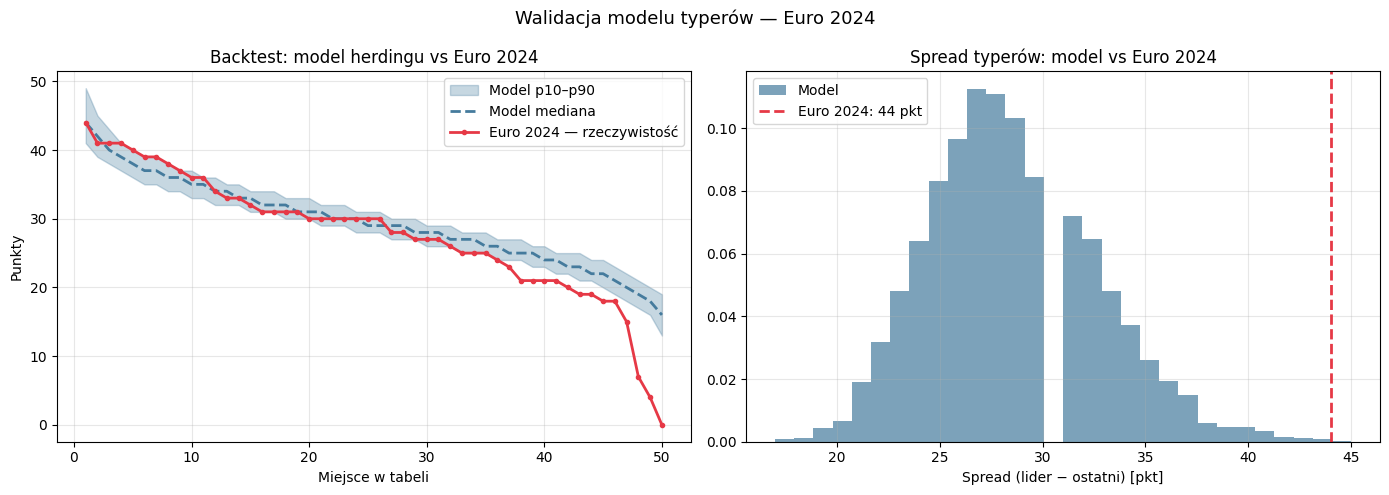

In [86]:
# === Backtest na Euro 2024 ===
EURO2024_XLSX = r'C:\Users\barto\Downloads\EURO 2024.xlsx'
EURO2024_SHEETS = [
    '14.06','15.06','16.06','17.06','18.06','19.06','20.06',
    '21.06','22.06','23.06','24.06','25.06','26.06',
    'O 29.06','O 01.07','O 30.06','O 02.07',
    'Q 05.07','Q 06.07','S 09.07','S 10.07','FINAŁ 14.07',
]

def _phase(n):
    if n.startswith('O '): return 'R16'
    if n.startswith('Q '): return 'QF'
    if n.startswith('S '): return 'SF'
    if 'FINA' in n: return 'F'
    return 'GS'

wb_e24 = openpyxl.load_workbook(EURO2024_XLSX, data_only=True)
euro_matches   = []
actual_pts_e24 = np.zeros(50)

for sname in EURO2024_SHEETS:
    ws   = wb_e24[sname]
    rows = list(ws.iter_rows(values_only=True))
    row3, row4 = rows[2], rows[3]
    phase = _phase(sname)

    for ci, val in enumerate(row3):
        if val != '-':
            continue
        hc, ac, pc = ci - 1, ci + 1, ci + 2
        ah, aa = row4[hc], row4[ac]
        if not (isinstance(ah, (int, float)) and isinstance(aa, (int, float))):
            continue
        ah, aa = int(ah), int(aa)

        name_h = str(row3[hc]).strip().replace('\xa0', '').upper()
        name_a = str(row3[ac]).strip().replace('\xa0', '').upper()
        ch = EURO2024_CODE_MAP.get(name_h)
        ca = EURO2024_CODE_MAP.get(name_a)
        lh, la = get_lams(ch, ca) if (ch and ca) else (None, None)
        euro_matches.append(dict(phase=phase, lam_h=lh, lam_a=la, ah=ah, aa=aa))

        for pi, player_row in enumerate(rows[4:]):
            if player_row[1] is None or pi >= 50:
                break
            bh, ba = player_row[hc], player_row[ac]
            if bh is None or ba is None:
                continue
            pts_val = player_row[pc]
            if isinstance(pts_val, (int, float)):
                actual_pts_e24[pi] += pts_val
            elif isinstance(bh, (int, float)) and isinstance(ba, (int, float)):
                bh, ba = int(bh), int(ba)
                if bh == ah and ba == aa:
                    actual_pts_e24[pi] += 3
                elif np.sign(bh - ba) == np.sign(ah - aa):
                    actual_pts_e24[pi] += 1

n_with_lam = sum(1 for m in euro_matches if m['lam_h'] is not None)
actual_sorted = np.sort(actual_pts_e24)[::-1]
print(f"Euro 2024: {len(euro_matches)} meczów, λ D-C dostępne dla {n_with_lam}")
print(f"Rzeczywiste punkty — top 5:     {actual_sorted[:5].astype(int).tolist()}")
print(f"Rzeczywiste punkty — ostatnie 5:{actual_sorted[-5:].astype(int).tolist()}")

# Symulacja 5 000× z modelem herdingu
bt_scores = np.zeros((N_TYPER_SIMS, 50))
for sim in range(N_TYPER_SIMS):
    pts = np.zeros(50)
    for m in euro_matches:
        if m['lam_h'] is None:
            continue
        pts += simulate_match_bets(m['lam_h'], m['lam_a'], m['ah'], m['aa'],
                                   50, dropout=DROPOUT_BY_PHASE[m['phase']])
    bt_scores[sim] = np.sort(pts)[::-1]

print(f"\n{'Rank':>5} | {'Actual':>7} | {'Sim śr':>7} | {'p10–p90':>12}")
for rank in [1, 3, 5, 10, 25, 50]:
    v = bt_scores[:, rank - 1]
    rng = f"{np.percentile(v, 10):.0f}–{np.percentile(v, 90):.0f}"
    print(f"{rank:>5} | {actual_sorted[rank-1]:>7.0f} | {v.mean():>7.1f} | {rng:>12}")

spread_actual = actual_sorted[0] - actual_sorted[-1]
spread_sim    = bt_scores[:, 0] - bt_scores[:, -1]
print(f"\nSpread lider–ostatni: actual={spread_actual:.0f},"
      f" sim śr={spread_sim.mean():.1f}"
      f" (p10={np.percentile(spread_sim,10):.0f},"
      f" p90={np.percentile(spread_sim,90):.0f})")

# Wykres
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(1, 51)
axes[0].fill_between(x,
    np.percentile(bt_scores, 10, axis=0),
    np.percentile(bt_scores, 90, axis=0),
    alpha=0.3, color='#457b9d', label='Model p10–p90')
axes[0].plot(x, np.median(bt_scores, axis=0), '--', color='#457b9d', lw=2, label='Model mediana')
axes[0].plot(x, actual_sorted, 'o-', color='#e63946', lw=2, ms=3, label='Euro 2024 — rzeczywistość')
axes[0].set_xlabel('Miejsce w tabeli')
axes[0].set_ylabel('Punkty')
axes[0].set_title('Backtest: model herdingu vs Euro 2024')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].hist(spread_sim, bins=30, color='#457b9d', alpha=0.7, density=True, label='Model')
axes[1].axvline(spread_actual, color='#e63946', lw=2, ls='--',
                label=f'Euro 2024: {spread_actual:.0f} pkt')
axes[1].set_xlabel('Spread (lider − ostatni) [pkt]')
axes[1].set_title('Spread typerów: model vs Euro 2024')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.suptitle('Walidacja modelu typerów — Euro 2024', fontsize=13)
plt.tight_layout()
plt.show()

MŚ 2026: 72 meczów grupowych + 32 knockout = 104 łącznie
Avg λ_h=1.565, λ_a=1.026 (aproksymacja KO)
Zakłady dodatkowe: 9 pytań × 2 pkt = max 18 pkt

=== Prognoza MŚ 2026 — rozkład punktów (50 graczy) ===
  (mecze + zakłady dodatkowe)
 Rank |     Śr |   p10 |   p50 |   p90
    1 |   78.2 |    71 |    78 |    86
    2 |   74.7 |    68 |    75 |    81
    3 |   72.7 |    67 |    73 |    79
    5 |   70.2 |    64 |    70 |    76
   10 |   66.2 |    61 |    66 |    72
   25 |   59.3 |    54 |    59 |    64
   50 |   42.0 |    36 |    42 |    48

Spread lider–ostatni: śr=36.2 pkt (p25=32, p75=40)
Avg korelacja wyników par graczy: r=0.172

E[pkt z zakładów dodatkowych] na gracza: 1.50 / 18 max


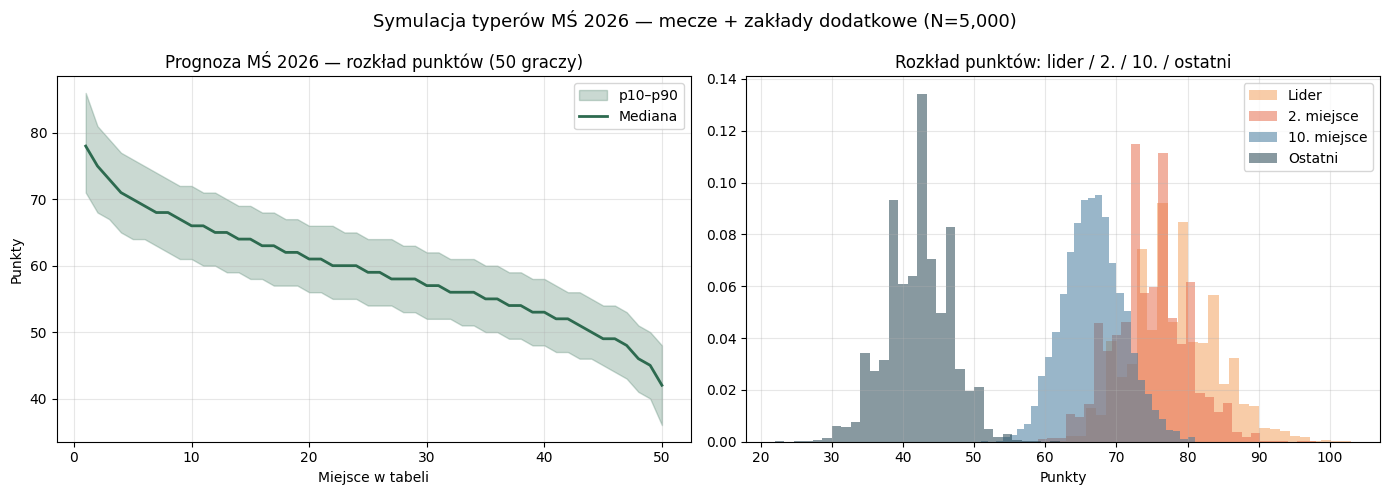

In [87]:
# === Prognoza MŚ 2026 ===

# Pre-compute λ dla fazy grupowej (72 mecze, stałe pary)
WC26_GS = []
for group_name, teams in GROUPS.items():
    for i in range(len(teams)):
        for j in range(i + 1, len(teams)):
            h, a = teams[i], teams[j]
            lh, la = get_lams(h, a)
            WC26_GS.append({'lam_h': lh, 'lam_a': la})

avg_lh = np.mean([m['lam_h'] for m in WC26_GS])
avg_la = np.mean([m['lam_a'] for m in WC26_GS])

# Dropout schedule fazy pucharowej:
# R32 (16 meczów) + R16 (8) → DROPOUT_R16 | QF (4) + SF (2) + 3rd (1) + F (1) → DROPOUT_KO
KO_DROPOUT = [DROPOUT_R16] * 24 + [DROPOUT_KO] * 8

# -----------------------------------------------------------------------
# Zakłady dodatkowe — rozkłady wyników z MC
# -----------------------------------------------------------------------
def _normed(counter, keys):
    vals = np.array([counter.get(k, 0) for k in keys], dtype=float)
    s = vals.sum()
    return vals / s if s > 0 else np.ones(len(vals)) / len(vals)

TEAMS_ARR = np.array(ALL_TEAMS)
P_FINALIST      = _normed(finalist_count,   ALL_TEAMS)
P_MOST_GOALS_GS = _normed(most_goals_group, ALL_TEAMS)
P_FIRST_RED     = _normed(first_red_card,   ALL_TEAMS)
P_THIRD_ADV     = _normed(third_advance,    ALL_TEAMS)

OG_RANGE    = np.arange(0, 15)
DRAWS_RANGE = np.arange(0, 50)
P_OG    = _normed(own_goals_dist, OG_RANGE)
P_DRAWS = _normed(draws_dist,     DRAWS_RANGE)

# Gracze z sekcji 13 (players dict musi byc zdefiniowany wczesniej)
def _player_dist(key, top_n=30):
    ranked = sorted(players.values(), key=lambda x: x[key], reverse=True)[:top_n]
    names = np.array([p['name'] for p in ranked])
    vals  = np.array([p[key] for p in ranked], dtype=float)
    return names, vals / vals.sum()

for p in players.values():
    p['exp_combined'] = p['exp_goals'] + p['exp_assists']

SCORER_NAMES,   P_SCORER   = _player_dist('exp_goals')
ASSISTER_NAMES, P_ASSISTER = _player_dist('exp_assists')
COMBINED_NAMES, P_COMBINED = _player_dist('exp_combined')

# 9 pytan specjalnych: (typ, outcomes_array, probs_array)
SPECIAL_QS = [
    ('TEAM',   TEAMS_ARR,       P_FINALIST),       # Q4  Finalista
    ('TEAM',   TEAMS_ARR,       P_MOST_GOALS_GS),  # Q5  Najwiecej goli GS
    ('TEAM',   TEAMS_ARR,       P_FIRST_RED),      # Q6  Pierwsza czerwona kartka
    ('TEAM',   TEAMS_ARR,       P_THIRD_ADV),      # Q7  Awans z 3. miejsca
    ('NUMBER', OG_RANGE,        P_OG),             # Q8  Bramki samobojcze
    ('NUMBER', DRAWS_RANGE,     P_DRAWS),          # Q9  Remisy w GS
    ('PLAYER', SCORER_NAMES,    P_SCORER),         # Q1  Krol strzeleow
    ('PLAYER', ASSISTER_NAMES,  P_ASSISTER),       # Q2  Najlepszy asystent
    ('PLAYER', COMBINED_NAMES,  P_COMBINED),       # Q3  Klasyfikacja kanadyjska
]
SPECIAL_PTS = 2

def simulate_special_bets(questions, n_players, herding_rate=HERDING_RATE):
    """
    Dla kazdego pytania:
      - losuje wynik turnieju z rozkladu MC
      - losuje typ kazdego gracza (herding_rate% → modalny, reszta → z rozkladu)
      - przyznaje SPECIAL_PTS za trafienie
    Zwraca array (n_players,) z punktami za zakłady dodatkowe.
    """
    pts = np.zeros(n_players)
    for _, _, probs in questions:
        n_out      = len(probs)
        outcome    = np.random.choice(n_out, p=probs)
        modal      = int(np.argmax(probs))
        is_herder  = np.random.random(n_players) < herding_rate
        indep_bets = np.random.choice(n_out, size=n_players, p=probs)
        bets       = np.where(is_herder, modal, indep_bets)
        pts       += np.where(bets == outcome, SPECIAL_PTS, 0)
    return pts

# --- Info startowe ---
print(f"MŚ 2026: {len(WC26_GS)} meczów grupowych + {len(KO_DROPOUT)} knockout = "
      f"{len(WC26_GS) + len(KO_DROPOUT)} łącznie")
print(f"Avg λ_h={avg_lh:.3f}, λ_a={avg_la:.3f} (aproksymacja KO)")
print(f"Zakłady dodatkowe: {len(SPECIAL_QS)} pytań × {SPECIAL_PTS} pkt = max {len(SPECIAL_QS)*SPECIAL_PTS} pkt")

# -----------------------------------------------------------------------
# Symulacja typerów
# -----------------------------------------------------------------------
wc_raw = np.zeros((N_TYPER_SIMS, N_TYPERS))

for sim in range(N_TYPER_SIMS):
    pts = np.zeros(N_TYPERS)
    for m in WC26_GS:
        ah = np.random.poisson(m['lam_h'])
        aa = np.random.poisson(m['lam_a'])
        pts += simulate_match_bets(m['lam_h'], m['lam_a'], ah, aa,
                                   N_TYPERS, dropout=DROPOUT_GS)
    for do in KO_DROPOUT:
        ah = np.random.poisson(avg_lh)
        aa = np.random.poisson(avg_la)
        pts += simulate_match_bets(avg_lh, avg_la, ah, aa, N_TYPERS, dropout=do)
    pts += simulate_special_bets(SPECIAL_QS, N_TYPERS)
    wc_raw[sim] = pts

wc_sorted = np.sort(wc_raw, axis=1)[:, ::-1]

# --- Wyniki ---
print(f"\n=== Prognoza MŚ 2026 — rozkład punktów ({N_TYPERS} graczy) ===")
print(f"  (mecze + zakłady dodatkowe)")
print(f"{'Rank':>5} | {'Śr':>6} | {'p10':>5} | {'p50':>5} | {'p90':>5}")
for rank in [1, 2, 3, 5, 10, 25, 50]:
    v = wc_sorted[:, rank - 1]
    print(f"{rank:>5} | {v.mean():>6.1f} | {np.percentile(v,10):>5.0f} | "
          f"{np.percentile(v,50):>5.0f} | {np.percentile(v,90):>5.0f}")

spread_wc = wc_sorted[:, 0] - wc_sorted[:, -1]
print(f"\nSpread lider–ostatni: śr={spread_wc.mean():.1f} pkt "
      f"(p25={np.percentile(spread_wc,25):.0f}, p75={np.percentile(spread_wc,75):.0f})")

corr_matrix = np.corrcoef(wc_raw.T)
avg_corr = corr_matrix[np.triu_indices_from(corr_matrix, k=1)].mean()
print(f"Avg korelacja wyników par graczy: r={avg_corr:.3f}")

# Ile pkt pochodzi z zakładów dodatkowych
spec_sample = np.array([simulate_special_bets(SPECIAL_QS, N_TYPERS) for _ in range(500)])
print(f"\nE[pkt z zakładów dodatkowych] na gracza: {spec_sample.mean():.2f} / {len(SPECIAL_QS)*SPECIAL_PTS} max")

# -----------------------------------------------------------------------
# Wykresy
# -----------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(1, N_TYPERS + 1)

axes[0].fill_between(x,
    np.percentile(wc_sorted, 10, axis=0),
    np.percentile(wc_sorted, 90, axis=0),
    alpha=0.25, color='#2d6a4f', label='p10–p90')
axes[0].plot(x, np.median(wc_sorted, axis=0), '-', color='#2d6a4f', lw=2, label='Mediana')
axes[0].set_xlabel('Miejsce w tabeli')
axes[0].set_ylabel('Punkty')
axes[0].set_title(f'Prognoza MŚ 2026 — rozkład punktów ({N_TYPERS} graczy)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

for rank, color, label in [(1, '#f4a261', 'Lider'), (2, '#e76f51', '2. miejsce'),
                            (10, '#457b9d', '10. miejsce'), (N_TYPERS, '#264653', 'Ostatni')]:
    axes[1].hist(wc_sorted[:, rank - 1], bins=30, alpha=0.55, density=True,
                 label=label, color=color)
axes[1].set_xlabel('Punkty')
axes[1].set_title('Rozkład punktów: lider / 2. / 10. / ostatni')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'Symulacja typerów MŚ 2026 — mecze + zakłady dodatkowe (N={N_TYPER_SIMS:,})', fontsize=13)
plt.tight_layout()
plt.show()
